In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Scikit-learn - Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Scikit-learn - Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# XGBoost
from xgboost import XGBRegressor

# Scikit-learn - Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Suppress warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Load Dataset & Initial Check

# Load the dataset
path = "/content/weather_prediction_dataset_light.csv"

df = pd.read_csv(path)

# Basic Info
print("=" * 60)
print(" DATASET SHAPE")
print("=" * 60)
print(f"  Rows    : {df.shape[0]}")
print(f"  Columns : {df.shape[1]}")

print("\n" + "=" * 60)
print(" FIRST 5 ROWS")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print(" DATASET INFO")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print(" STATISTICAL SUMMARY")
print("=" * 60)
display(df.describe())

print("\n" + "=" * 60)
print(" MISSING VALUES PER COLUMN")
print("=" * 60)
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print("   No missing values found!")
else:
    print(missing)

print("\n" + "=" * 60)
print(" COLUMN NAMES")
print("=" * 60)
for col in df.columns:
    print(f"  {col}")

 DATASET SHAPE
  Rows    : 3654
  Columns : 91

 FIRST 5 ROWS


,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
0,20000101,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,...,-15.2,-17.0,-13.4,0.97,1.0275,0.25,0.04,8.5,7.2,9.8
1,20000102,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,...,-13.7,-15.0,-12.3,0.99,1.0293,0.17,0.16,7.9,6.6,9.2
2,20000103,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,...,-9.2,-12.5,-5.8,0.91,1.0267,0.27,0.00,8.1,6.6,9.6
3,20000104,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,...,-5.6,-7.0,-4.2,0.95,1.0222,0.11,0.44,8.6,6.4,10.8
4,20000105,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,...,-7.6,-9.4,-5.8,0.95,1.0209,0.39,0.04,8.0,6.4,9.5



 DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3654 entries, 0 to 3653
Data columns (total 91 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   DATE                         3654 non-null   int64  
 1   MONTH                        3654 non-null   int64  
 2   BASEL_cloud_cover            3654 non-null   int64  
 3   BASEL_humidity               3654 non-null   float64
 4   BASEL_pressure               3654 non-null   float64
 5   BASEL_global_radiation       3654 non-null   float64
 6   BASEL_precipitation          3654 non-null   float64
 7   BASEL_sunshine               3654 non-null   float64
 8   BASEL_temp_mean              3654 non-null   float64
 9   BASEL_temp_min               3654 non-null   float64
 10  BASEL_temp_max               3654 non-null   float64
 11  DE_BILT_cloud_cover          3654 non-null   int64  
 12  DE_BILT_humidity             3654 non-null   float64
 13  DE_

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
count,3.654000e+03,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,...,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000,3654.000000
mean,2.004568e+07,6.520799,5.418446,0.745107,1.017876,1.330380,0.234849,4.661193,11.022797,6.989135,...,-4.626327,-6.884319,-2.352244,0.781872,1.016639,1.369787,0.186100,12.205802,7.860536,16.551779
std,2.874287e+04,3.450083,2.325497,0.107788,0.007962,0.935348,0.536267,4.330112,7.414754,6.653356,...,6.987080,7.120333,6.972886,0.115572,0.018885,0.926472,0.422151,6.467155,5.692256,7.714924
min,2.000010e+07,1.000000,0.000000,0.380000,0.985600,0.050000,0.000000,0.000000,-9.300000,-16.000000,...,-26.600000,-30.300000,-24.700000,0.330000,0.000300,0.050000,0.000000,-6.200000,-13.000000,-3.100000
25%,2.002070e+07,4.000000,4.000000,0.670000,1.013300,0.530000,0.000000,0.500000,5.300000,2.000000,...,-9.400000,-11.800000,-7.100000,0.700000,1.012100,0.550000,0.000000,7.600000,3.700000,10.800000
50%,2.004567e+07,7.000000,6.000000,0.760000,1.017700,1.110000,0.000000,3.600000,11.400000,7.300000,...,-4.400000,-6.400000,-2.200000,0.800000,1.017300,1.235000,0.000000,12.300000,8.300000,16.600000
75%,2.007070e+07,10.000000,7.000000,0.830000,1.022700,2.060000,0.210000,8.000000,16.900000,12.400000,...,0.700000,-1.100000,2.700000,0.870000,1.022200,2.090000,0.160000,17.200000,12.300000,22.400000
max,2.010010e+07,12.000000,8.000000,0.980000,1.040800,3.550000,7.570000,15.300000,29.000000,20.800000,...,13.800000,8.700000,14.300000,1.000000,1.041400,3.560000,6.200000,31.200000,22.600000,39.800000



 MISSING VALUES PER COLUMN
   No missing values found!

 COLUMN NAMES
  DATE
  MONTH
  BASEL_cloud_cover
  BASEL_humidity
  BASEL_pressure
  BASEL_global_radiation
  BASEL_precipitation
  BASEL_sunshine
  BASEL_temp_mean
  BASEL_temp_min
  BASEL_temp_max
  DE_BILT_cloud_cover
  DE_BILT_humidity
  DE_BILT_pressure
  DE_BILT_global_radiation
  DE_BILT_precipitation
  DE_BILT_sunshine
  DE_BILT_temp_mean
  DE_BILT_temp_min
  DE_BILT_temp_max
  DRESDEN_cloud_cover
  DRESDEN_humidity
  DRESDEN_global_radiation
  DRESDEN_precipitation
  DRESDEN_sunshine
  DRESDEN_temp_mean
  DRESDEN_temp_min
  DRESDEN_temp_max
  DUSSELDORF_cloud_cover
  DUSSELDORF_humidity
  DUSSELDORF_pressure
  DUSSELDORF_global_radiation
  DUSSELDORF_precipitation
  DUSSELDORF_sunshine
  DUSSELDORF_temp_mean
  DUSSELDORF_temp_min
  DUSSELDORF_temp_max
  HEATHROW_cloud_cover
  HEATHROW_humidity
  HEATHROW_pressure
  HEATHROW_global_radiation
  HEATHROW_precipitation
  HEATHROW_sunshine
  HEATHROW_temp_mean
  HEATHROW_temp

  PRECIPITATION COLUMNS FOUND
  BASEL_precipitation
  DE_BILT_precipitation
  DRESDEN_precipitation
  DUSSELDORF_precipitation
  HEATHROW_precipitation
  KASSEL_precipitation
  MAASTRICHT_precipitation
  MALMO_precipitation
  MUENCHEN_precipitation
  SONNBLICK_precipitation
  TOURS_precipitation

  Total cities with precipitation data: 11

 AVERAGE DAILY PRECIPITATION PER CITY (mm)
SONNBLICK_precipitation     0.541
MUENCHEN_precipitation      0.262
DE_BILT_precipitation       0.237
BASEL_precipitation         0.235
MAASTRICHT_precipitation    0.221
DUSSELDORF_precipitation    0.218
KASSEL_precipitation        0.202
TOURS_precipitation         0.186
HEATHROW_precipitation      0.178
DRESDEN_precipitation       0.176
MALMO_precipitation         0.167
dtype: float64


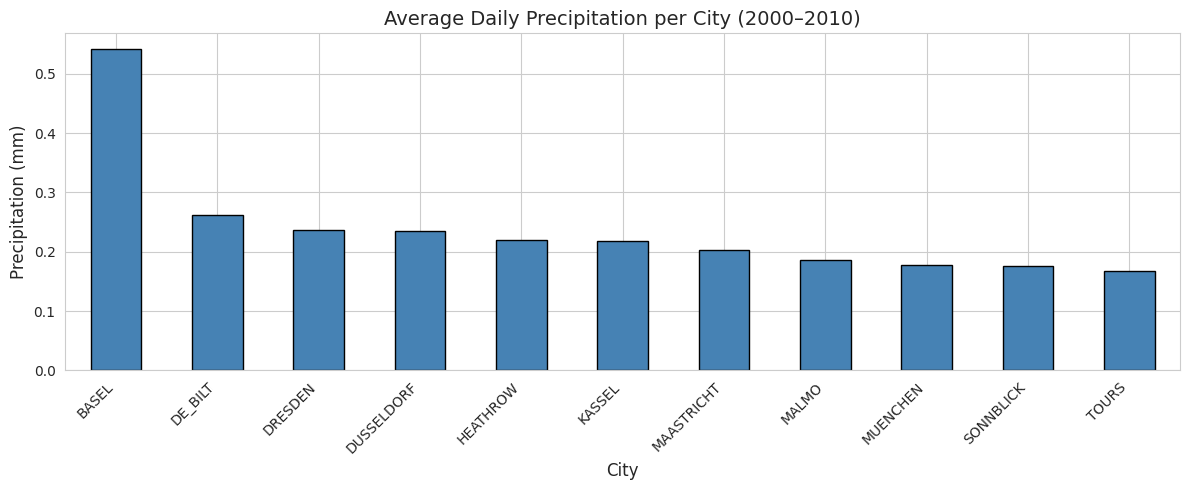

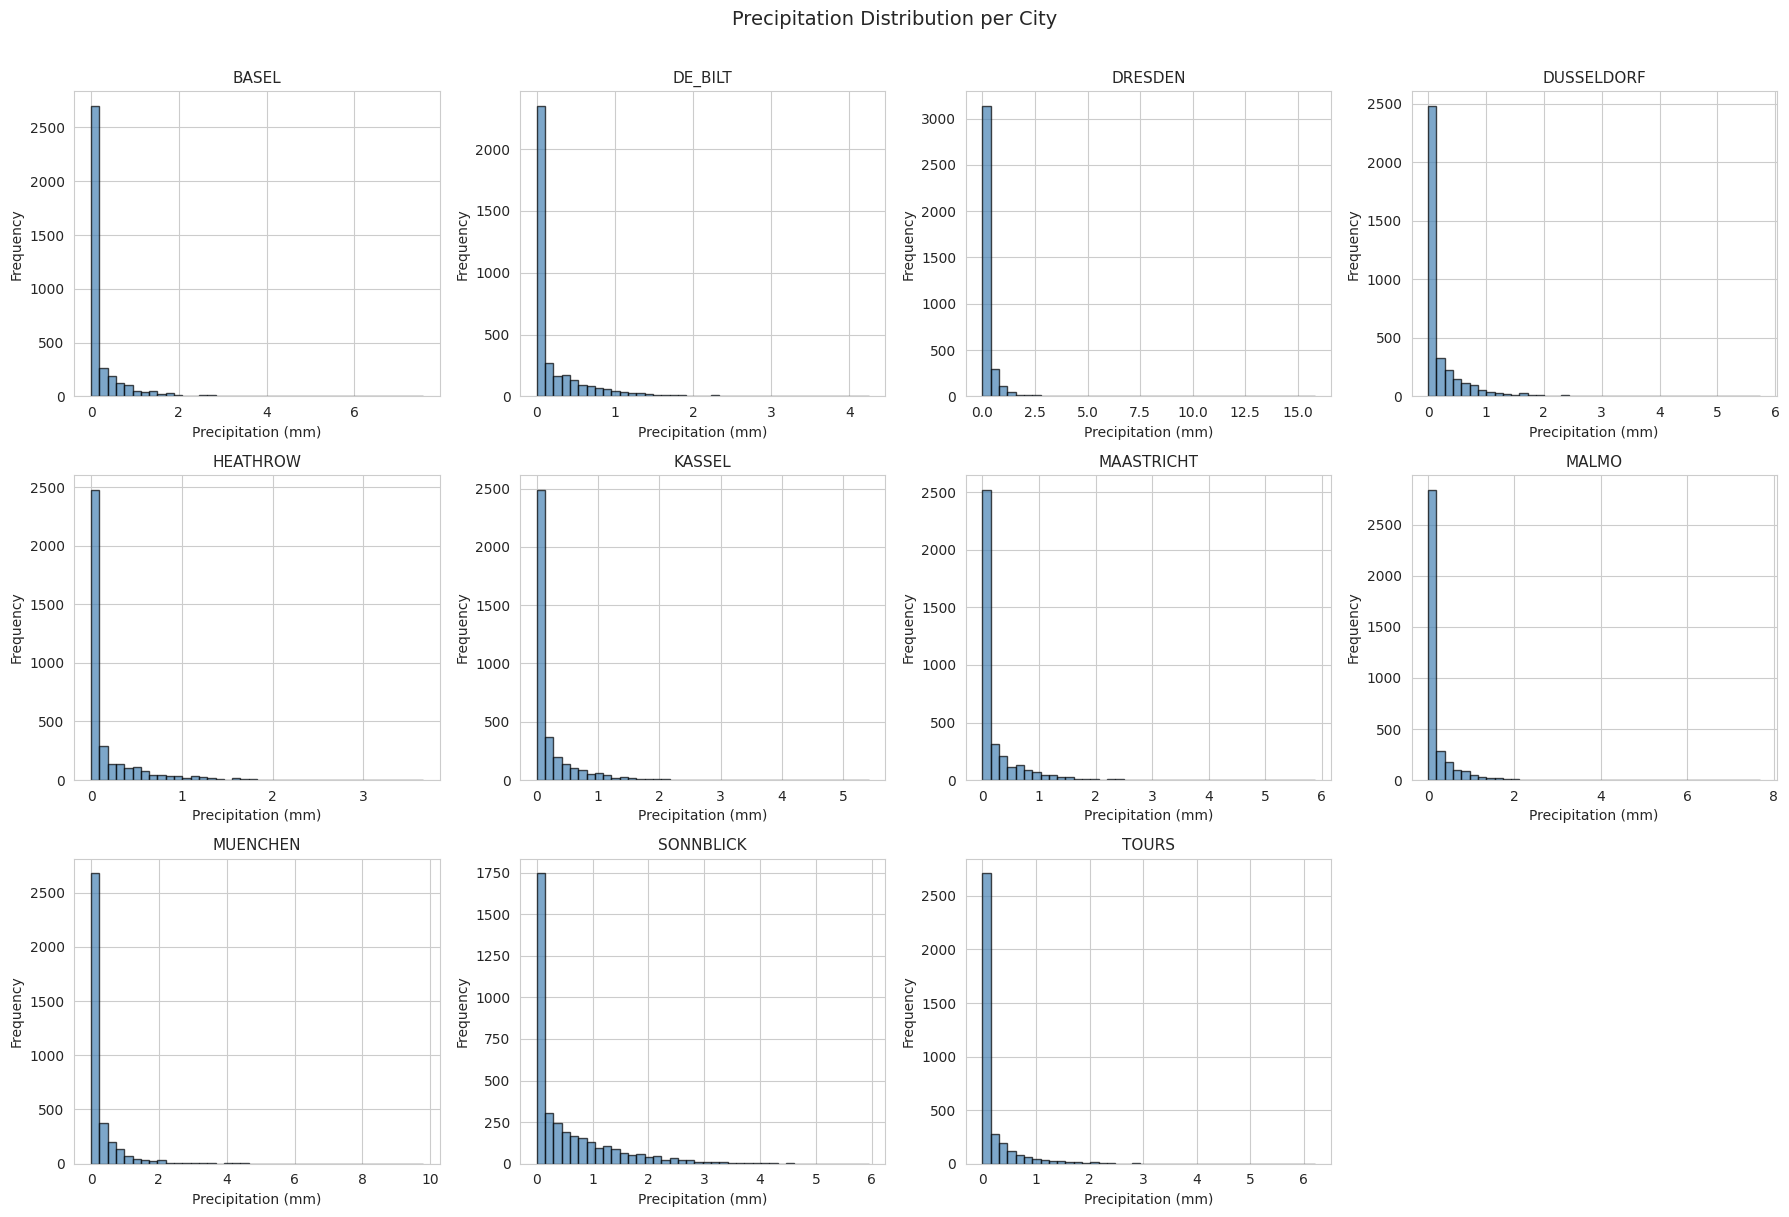

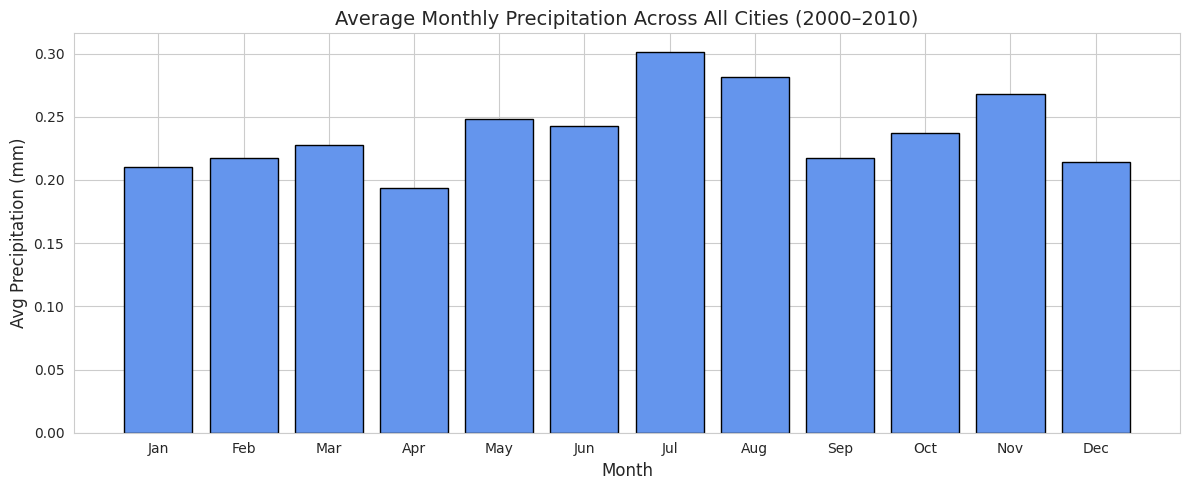

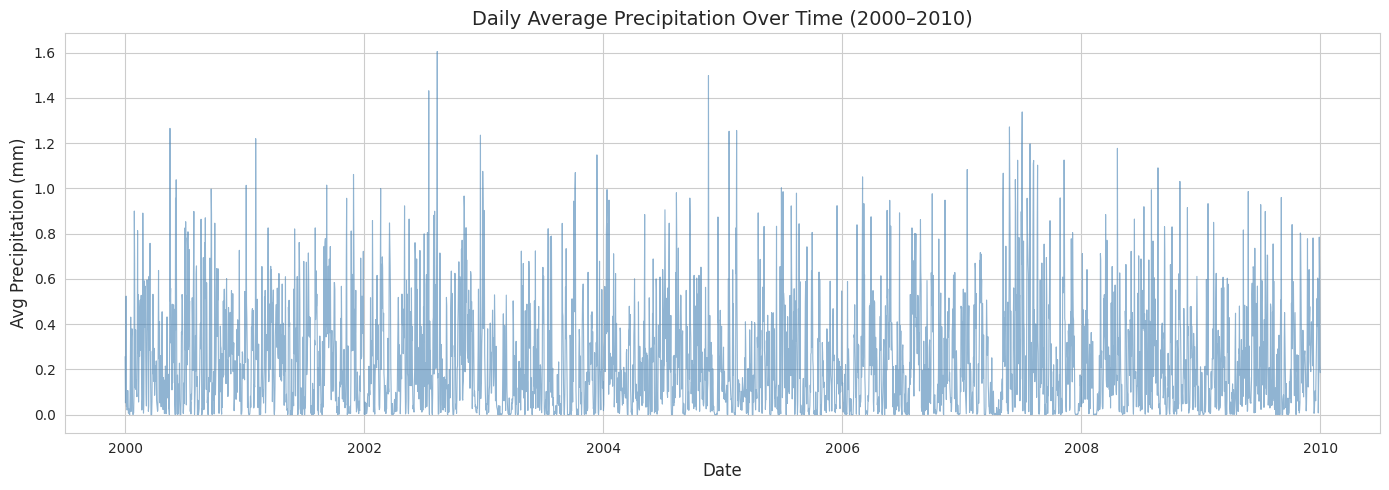

 Precipitation EDA complete!


In [ ]:
# EDA - Precipitation Analysis

# Convert DATE to datetime
df['DATE'] = pd.to_datetime(df['DATE'], format='%Y%m%d')

# Extract all precipitation columns
precip_cols = [col for col in df.columns if col.endswith('_precipitation')]
cities = [col.replace('_precipitation', '') for col in precip_cols]

print("=" * 60)
print("  PRECIPITATION COLUMNS FOUND")
print("=" * 60)
for col in precip_cols:
    print(f"  {col}")

print(f"\n  Total cities with precipitation data: {len(precip_cols)}")

# 1. Average Precipitation per City
print("\n" + "=" * 60)
print(" AVERAGE DAILY PRECIPITATION PER CITY (mm)")
print("=" * 60)
avg_precip = df[precip_cols].mean().sort_values(ascending=False)
print(avg_precip.round(3))

# Bar chart - Average precipitation per city
plt.figure(figsize=(12, 5))
avg_precip.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Daily Precipitation per City (2000–2010)', fontsize=14)
plt.xlabel('City', fontsize=12)
plt.ylabel('Precipitation (mm)', fontsize=12)
plt.xticks([i for i in range(len(precip_cols))],
           [c.replace('_precipitation','') for c in precip_cols],
           rotation=45, ha='right')
plt.tight_layout()
plt.show()

#  2. Precipitation Distribution per City
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(precip_cols):
    axes[i].hist(df[col], bins=40, color='steelblue',
                 edgecolor='black', alpha=0.7)
    axes[i].set_title(col.replace('_precipitation', ''), fontsize=11)
    axes[i].set_xlabel('Precipitation (mm)')
    axes[i].set_ylabel('Frequency')

# Hide unused subplots
for j in range(len(precip_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Precipitation Distribution per City', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#  3. Monthly Average Precipitation (all cities combined)
df['avg_precipitation'] = df[precip_cols].mean(axis=1)

monthly_avg = df.groupby('MONTH')['avg_precipitation'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 5))
plt.bar(month_names, monthly_avg.values, color='cornflowerblue', edgecolor='black')
plt.title('Average Monthly Precipitation Across All Cities (2000–2010)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Avg Precipitation (mm)', fontsize=12)
plt.tight_layout()
plt.show()

#  4. Time Series of Precipitation
plt.figure(figsize=(14, 5))
plt.plot(df['DATE'], df['avg_precipitation'],
         color='steelblue', alpha=0.6, linewidth=0.8)
plt.title('Daily Average Precipitation Over Time (2000–2010)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Avg Precipitation (mm)', fontsize=12)
plt.tight_layout()
plt.show()

print(" Precipitation EDA complete!")

 BASEL FEATURES (Representative City)
  BASEL_cloud_cover
  BASEL_humidity
  BASEL_pressure
  BASEL_global_radiation
  BASEL_precipitation
  BASEL_sunshine
  BASEL_temp_mean
  BASEL_temp_min
  BASEL_temp_max


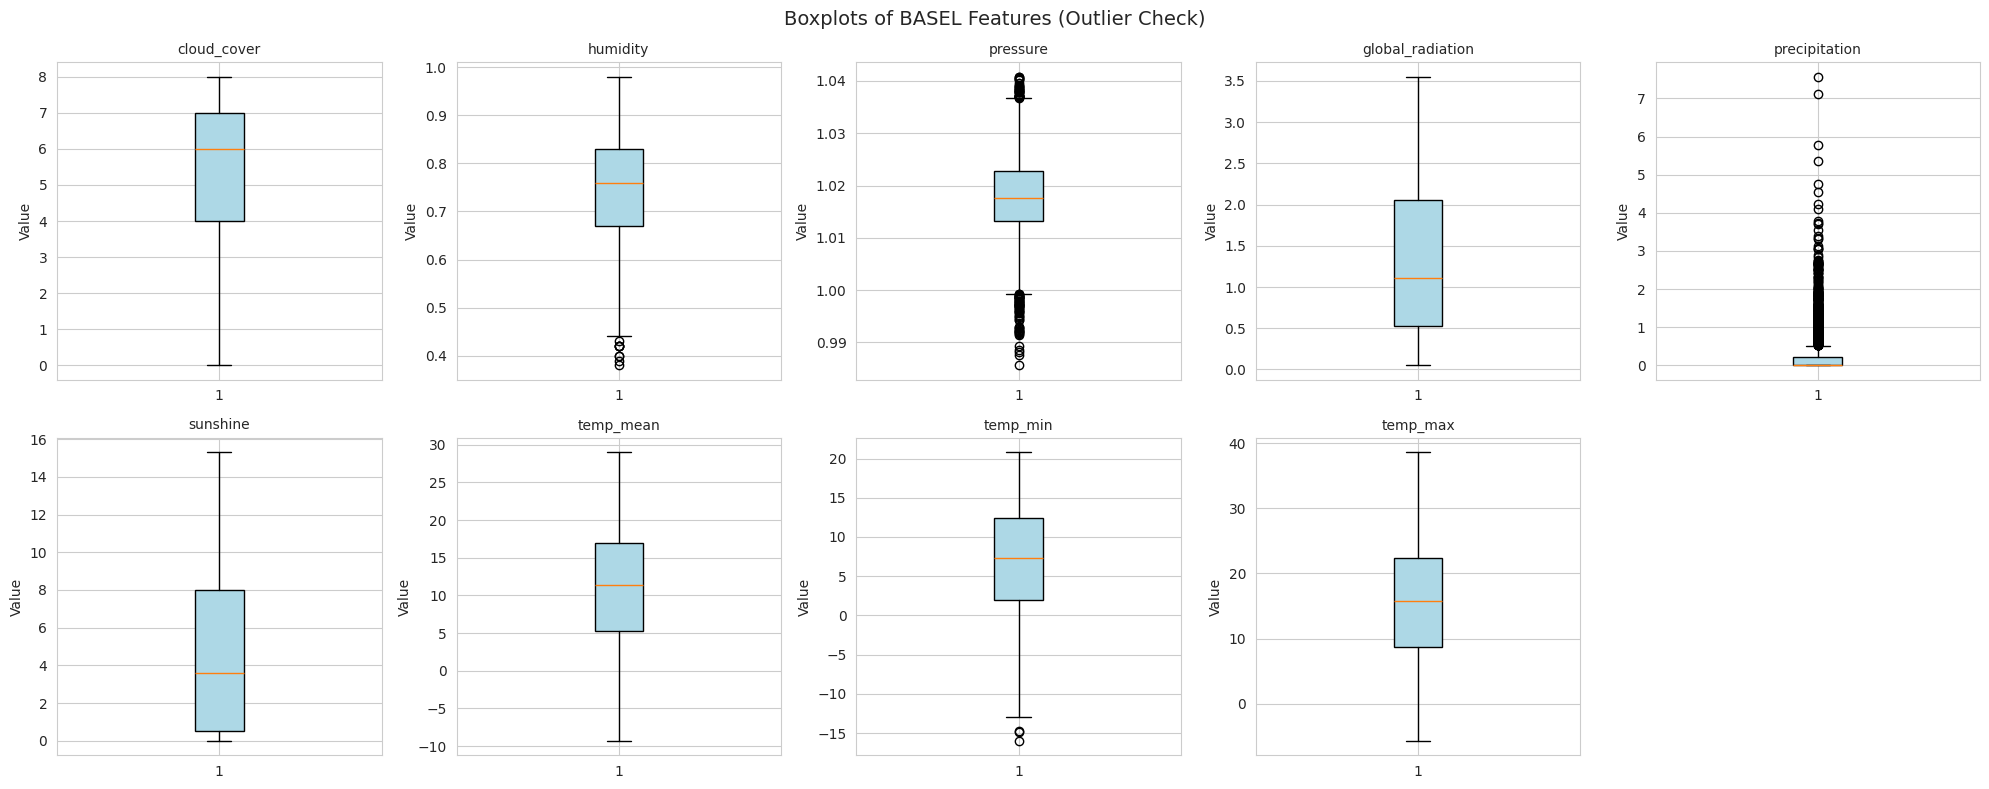

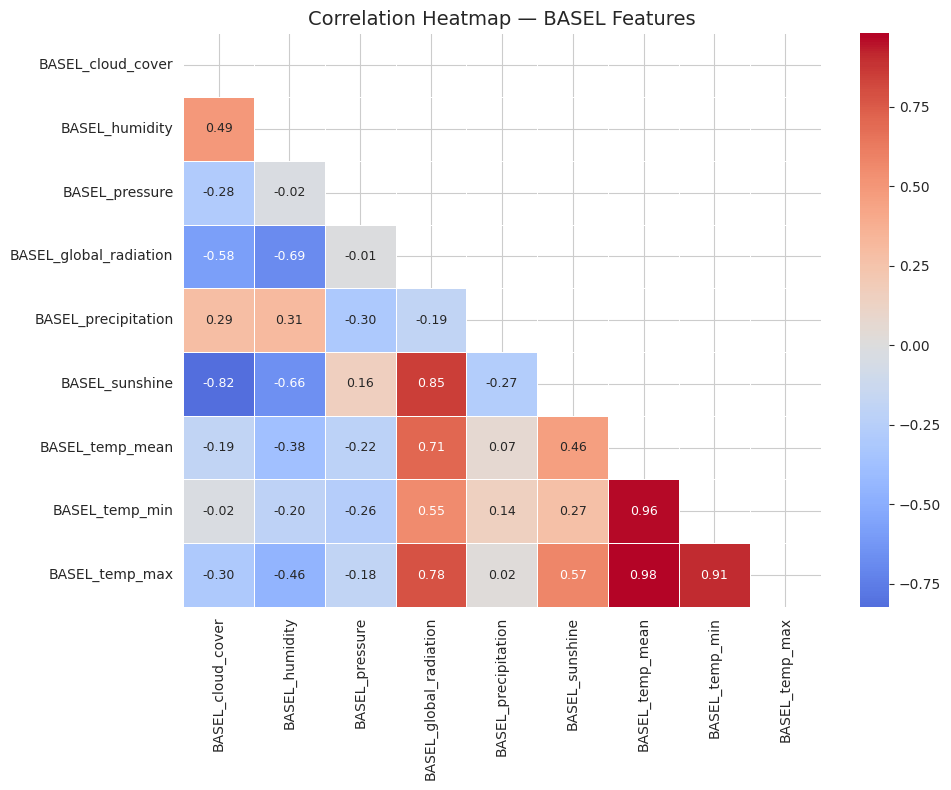


 CORRELATION WITH BASEL PRECIPITATION (sorted)
BASEL_humidity            0.3078
BASEL_pressure            0.3034
BASEL_cloud_cover         0.2883
BASEL_sunshine            0.2728
BASEL_global_radiation    0.1884
BASEL_temp_min            0.1424
BASEL_temp_mean           0.0668
BASEL_temp_max            0.0216
Name: BASEL_precipitation, dtype: float64


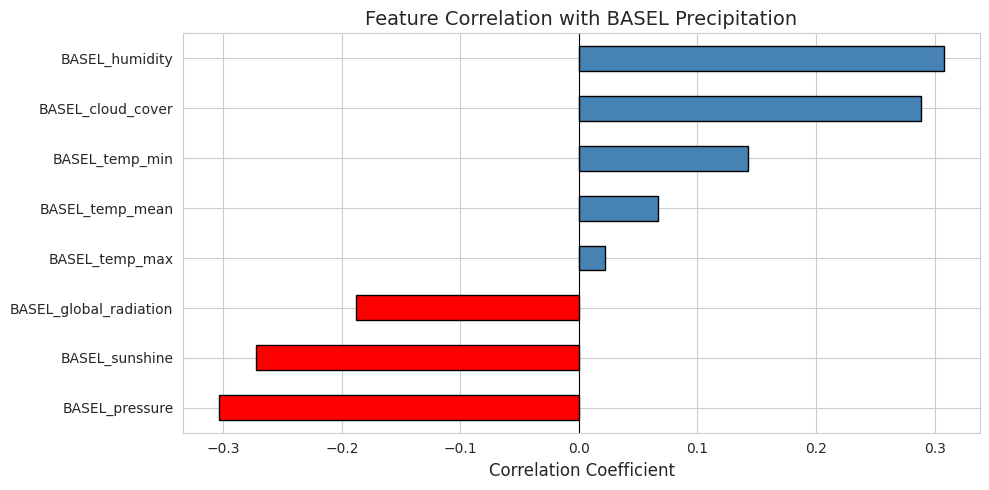

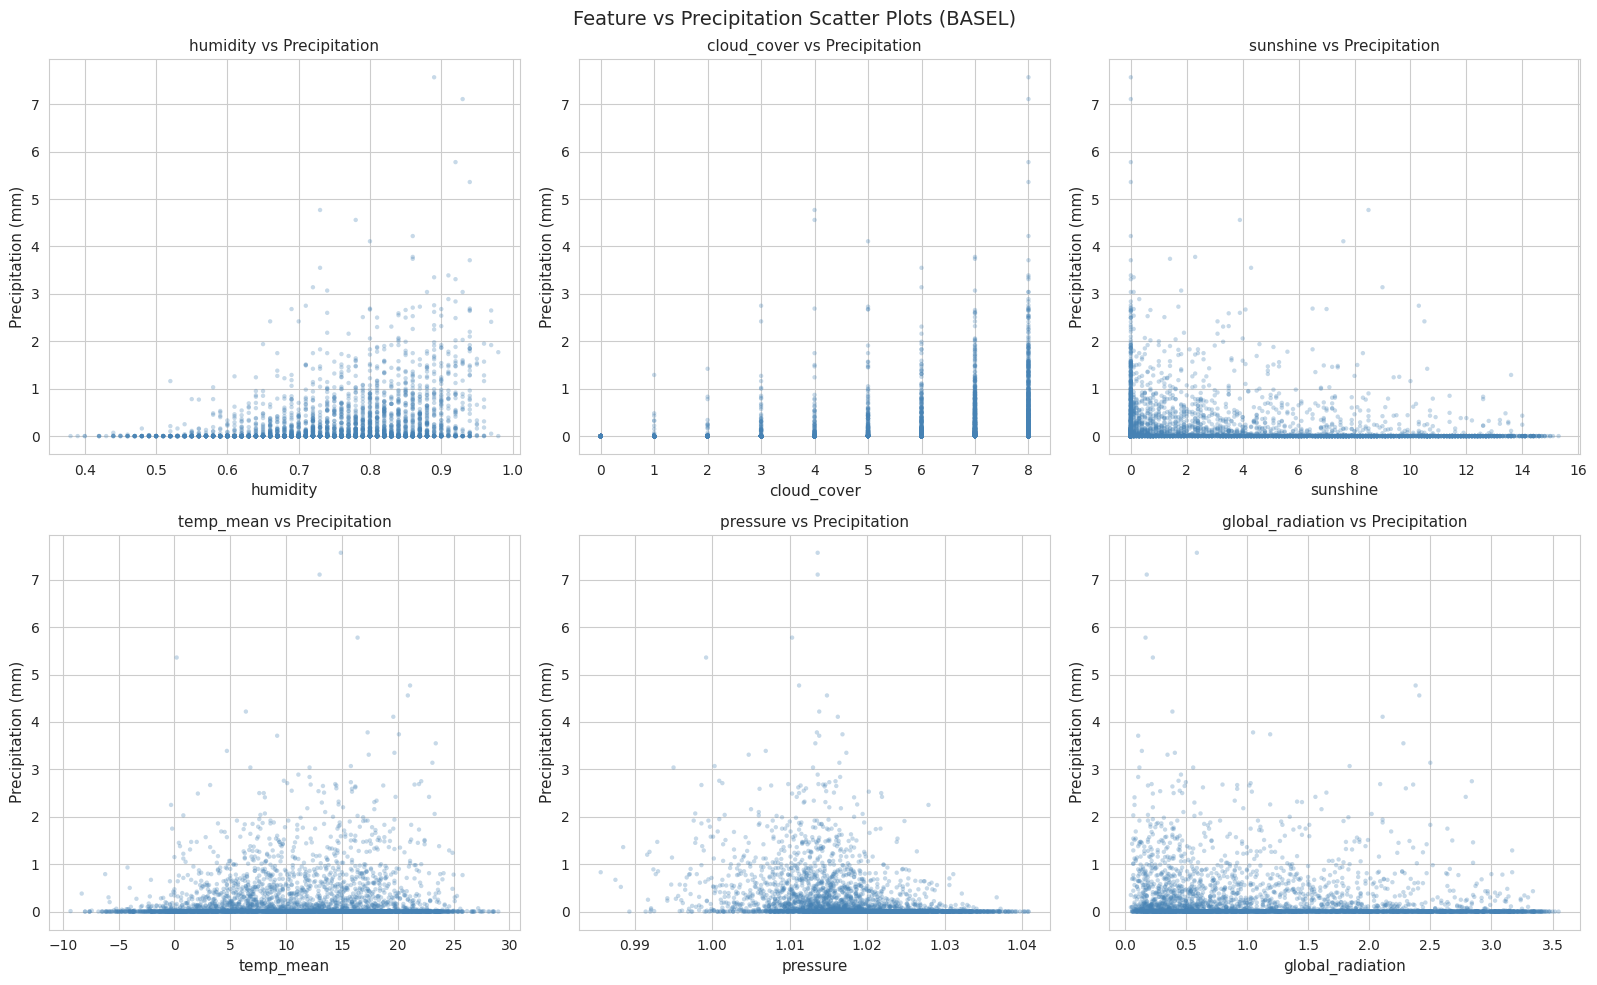

 Feature EDA complete!


In [ ]:
#  EDA - Feature Distributions & Correlations

#  1. Focus on BASEL as representative city
# (Basel has the most complete set of features)
basel_cols = [col for col in df.columns if col.startswith('BASEL')]

print("=" * 60)
print(" BASEL FEATURES (Representative City)")
print("=" * 60)
for col in basel_cols:
    print(f"  {col}")

#  2. Boxplots for BASEL Features
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(basel_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(col.replace('BASEL_', ''), fontsize=10)
    axes[i].set_ylabel('Value')

for j in range(len(basel_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots of BASEL Features (Outlier Check)', fontsize=14)
plt.tight_layout()
plt.show()

#  3. Correlation Heatmap for BASEL
plt.figure(figsize=(10, 8))
basel_corr = df[basel_cols].corr()
mask = np.triu(np.ones_like(basel_corr, dtype=bool))
sns.heatmap(basel_corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={"size": 9})
plt.title('Correlation Heatmap — BASEL Features', fontsize=14)
plt.tight_layout()
plt.show()

#  4. Correlation of all features with BASEL precipitation
print("\n" + "=" * 60)
print(" CORRELATION WITH BASEL PRECIPITATION (sorted)")
print("=" * 60)
corr_with_precip = df[basel_cols].corr()['BASEL_precipitation'].drop('BASEL_precipitation')
corr_sorted = corr_with_precip.abs().sort_values(ascending=False)
print(corr_sorted.round(4))

# Bar chart
plt.figure(figsize=(10, 5))
corr_with_precip.sort_values().plot(kind='barh',
                                    color=['red' if x < 0 else 'steelblue'
                                           for x in corr_with_precip.sort_values()],
                                    edgecolor='black')
plt.title('Feature Correlation with BASEL Precipitation', fontsize=14)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

#  5. Scatter plots: Key features vs BASEL precipitation
key_features = ['BASEL_humidity', 'BASEL_cloud_cover',
                'BASEL_sunshine', 'BASEL_temp_mean',
                'BASEL_pressure', 'BASEL_global_radiation']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    axes[i].scatter(df[feat], df['BASEL_precipitation'],
                    alpha=0.3, color='steelblue', edgecolors='none', s=10)
    axes[i].set_xlabel(feat.replace('BASEL_', ''), fontsize=11)
    axes[i].set_ylabel('Precipitation (mm)', fontsize=11)
    axes[i].set_title(f'{feat.replace("BASEL_", "")} vs Precipitation', fontsize=11)

plt.suptitle('Feature vs Precipitation Scatter Plots (BASEL)', fontsize=14)
plt.tight_layout()
plt.show()

print(" Feature EDA complete!")

In [ ]:
# Smart City Detection and Feature Extraction

# Automatically detect all cities and their available features
def detect_cities(dataframe):
    exclude_cols = ['DATE', 'MONTH']
    city_features = {}

    for col in dataframe.columns:
        if col in exclude_cols:
            continue
        parts = col.split('_', 1) if not col.startswith('DE_BILT') else ['DE_BILT', col[7:]]

        if col.startswith('DE_BILT'):
            city = 'DE_BILT'
            feature = col.replace('DE_BILT_', '')
        else:
            underscore_idx = col.index('_')
            city = col[:underscore_idx]
            feature = col[underscore_idx+1:]

        if city not in city_features:
            city_features[city] = []
        city_features[city].append(feature)

    return city_features

city_features = detect_cities(df)

print("Cities detected and their available features:")
print()
for city, features in city_features.items():
    print(f"  {city} ({len(features)} features):")
    for f in features:
        print(f"      {f}")
    print()

# Check which cities have precipitation (target variable)
cities_with_precip = [
    city for city, feats in city_features.items()
    if 'precipitation' in feats
]

print("Cities with precipitation data:", len(cities_with_precip))
for c in cities_with_precip:
    print("  ", c)

Cities detected and their available features:

  BASEL (9 features):
      cloud_cover
      humidity
      pressure
      global_radiation
      precipitation
      sunshine
      temp_mean
      temp_min
      temp_max

  DE_BILT (9 features):
      cloud_cover
      humidity
      pressure
      global_radiation
      precipitation
      sunshine
      temp_mean
      temp_min
      temp_max

  DRESDEN (8 features):
      cloud_cover
      humidity
      global_radiation
      precipitation
      sunshine
      temp_mean
      temp_min
      temp_max

  DUSSELDORF (9 features):
      cloud_cover
      humidity
      pressure
      global_radiation
      precipitation
      sunshine
      temp_mean
      temp_min
      temp_max

  HEATHROW (9 features):
      cloud_cover
      humidity
      pressure
      global_radiation
      precipitation
      sunshine
      temp_mean
      temp_min
      temp_max

  KASSEL (8 features):
      humidity
      pressure
      global_radiation
     

In [ ]:
# Core ML Pipeline Function

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def get_city_data(dataframe, city, city_feat_dict):
    """
    Extracts feature matrix X and target y for a given city.
    Automatically uses all available features except precipitation as target.
    Also includes MONTH as a seasonal feature.
    """
    available_features = city_feat_dict[city]
    feature_names = [
        f for f in available_features if f != 'precipitation'
    ]

    col_names  = [f"{city}_{f}" for f in feature_names]
    target_col = f"{city}_precipitation"

    col_names.append('MONTH')

    X = dataframe[col_names]
    y = dataframe[target_col]

    return X, y, col_names


def train_evaluate_models(X, y, city_name):
    """
    Trains all 4 models on given X and y.
    Returns a dictionary of results for each model.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    models = {
        'Linear Regression' : LinearRegression(),
        'Decision Tree'     : DecisionTreeRegressor(random_state=42),
        'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
        'XGBoost'           : XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    }

    results = []

    for model_name, model in models.items():
        if model_name == 'Linear Regression':
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2   = r2_score(y_test, y_pred)

        results.append({
            'City'       : city_name,
            'Model'      : model_name,
            'MAE'        : round(mae, 4),
            'RMSE'       : round(rmse, 4),
            'R2_Score'   : round(r2, 4)
        })

    return results, models, X_train, X_test, y_train, y_test, scaler


def get_feature_importance(models, feature_names):
    """
    Extracts feature importances from Random Forest and XGBoost.
    """
    importance_dict = {}

    for model_name in ['Random Forest', 'XGBoost']:
        model = models[model_name]
        if hasattr(model, 'feature_importances_'):
            importance_dict[model_name] = pd.Series(
                model.feature_importances_,
                index=feature_names
            ).sort_values(ascending=False)

    return importance_dict


print("Pipeline functions defined successfully.")
print()
print("Functions available:")
print("  get_city_data()          : extracts X and y for any city")
print("  train_evaluate_models()  : trains all 4 models and returns metrics")
print("  get_feature_importance() : extracts feature importances")

Pipeline functions defined successfully.

Functions available:
  get_city_data()          : extracts X and y for any city
  train_evaluate_models()  : trains all 4 models and returns metrics
  get_feature_importance() : extracts feature importances


In [ ]:
# Run Pipeline Across All Cities

all_results     = []
all_models      = {}
all_splits      = {}
all_importances = {}

print("Running ML pipeline for all cities...")
print()

for city in cities_with_precip:
    X, y, col_names = get_city_data(df, city, city_features)
    feature_names   = col_names

    results, models, X_train, X_test, y_train, y_test, scaler = train_evaluate_models(
        X, y, city
    )

    importances = get_feature_importance(models, feature_names)

    all_results.extend(results)
    all_models[city]      = models
    all_importances[city] = importances
    all_splits[city]      = {
        'X_train' : X_train,
        'X_test'  : X_test,
        'y_train' : y_train,
        'y_test'  : y_test,
        'scaler'  : scaler,
        'features': feature_names
    }

    best = max(results, key=lambda x: x['R2_Score'])
    print(f"  {city:15s} done | Best model: {best['Model']:20s} | R2: {best['R2_Score']}")

results_df = pd.DataFrame(all_results)

print()
print("Full Results Table:")
display(results_df)

print()
print(f"Total models trained: {len(all_results)} ({len(cities_with_precip)} cities x 4 models)")

Running ML pipeline for all cities...

  BASEL           done | Best model: Random Forest        | R2: 0.2726
  DE_BILT         done | Best model: Random Forest        | R2: 0.2676
  DRESDEN         done | Best model: Random Forest        | R2: 0.1338
  DUSSELDORF      done | Best model: Random Forest        | R2: 0.2048
  HEATHROW        done | Best model: Linear Regression    | R2: 0.272
  KASSEL          done | Best model: Random Forest        | R2: 0.2273
  MAASTRICHT      done | Best model: Random Forest        | R2: 0.3431
  MALMO           done | Best model: Linear Regression    | R2: 0.0414
  MUENCHEN        done | Best model: Random Forest        | R2: 0.2138
  SONNBLICK       done | Best model: Random Forest        | R2: 0.2909
  TOURS           done | Best model: Random Forest        | R2: 0.3232
  avg             done | Best model: Random Forest        | R2: 0.0106

Full Results Table:


,City,Model,MAE,RMSE,R2_Score
0,BASEL,Linear Regression,0.2798,0.4773,0.2191
1,BASEL,Decision Tree,0.2995,0.6581,-0.4848
2,BASEL,Random Forest,0.2346,0.4607,0.2726
3,BASEL,XGBoost,0.2434,0.4996,0.1443
4,DE_BILT,Linear Regression,0.2583,0.4022,0.2146
5,DE_BILT,Decision Tree,0.2767,0.4987,-0.2077
6,DE_BILT,Random Forest,0.2257,0.3884,0.2676
7,DE_BILT,XGBoost,0.2354,0.4095,0.1860
8,DRESDEN,Linear Regression,0.2142,0.3652,0.1220
9,DRESDEN,Decision Tree,0.2376,0.4909,-0.5869



Total models trained: 48 (12 cities x 4 models)


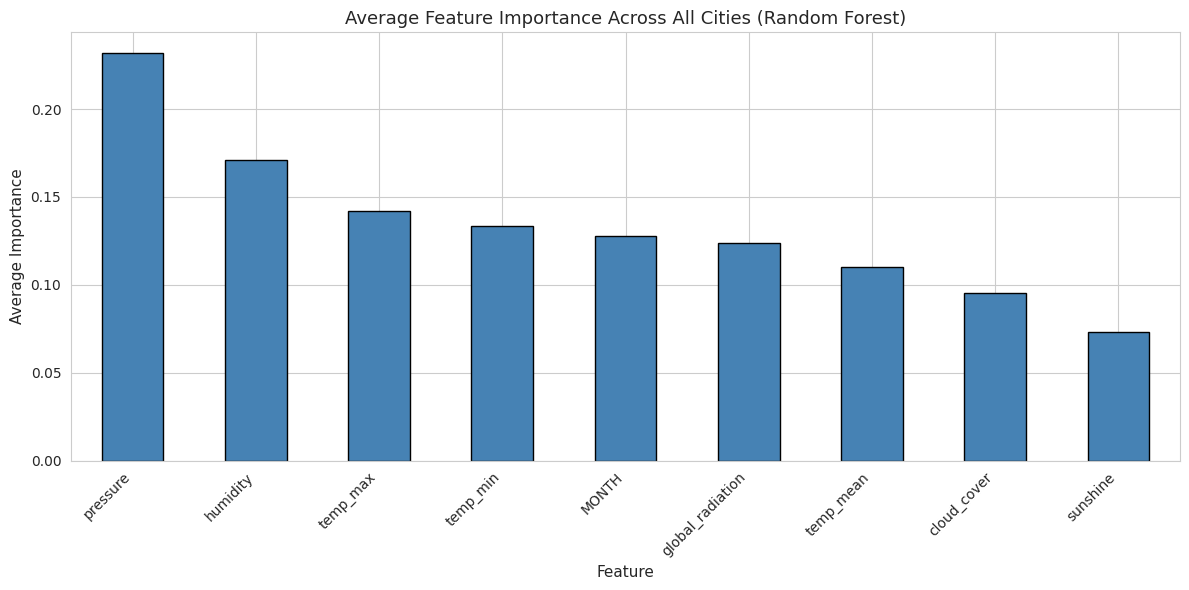

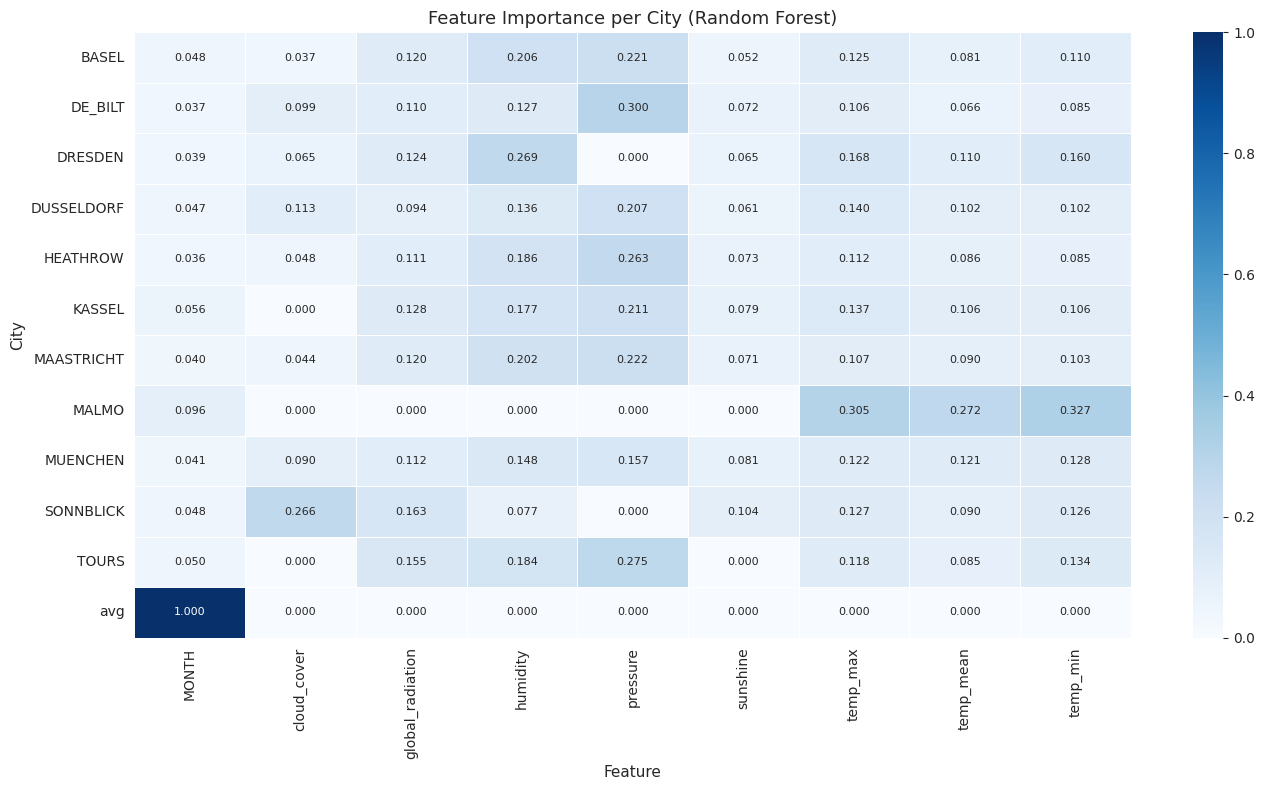

Top 3 most important features globally:

Feature
pressure    0.2320
humidity    0.1710
temp_max    0.1422
Name: Importance, dtype: float64


In [ ]:
# Global Feature Importance Across All Cities

# Aggregate Random Forest importances across all cities
all_rf_importances = []

for city in cities_with_precip:
    if 'Random Forest' in all_importances[city]:
        imp = all_importances[city]['Random Forest'].reset_index()
        imp.columns = ['Feature', 'Importance']
        imp['City']    = city
        imp['Feature'] = imp['Feature'].str.replace(f'{city}_', '', regex=False)
        all_rf_importances.append(imp)

rf_importance_df = pd.concat(all_rf_importances, ignore_index=True)

# Average importance per feature type across cities
avg_importance = rf_importance_df.groupby('Feature')['Importance'].mean()
avg_importance = avg_importance.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
avg_importance.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Feature Importance Across All Cities (Random Forest)', fontsize=13)
plt.xlabel('Feature', fontsize=11)
plt.ylabel('Average Importance', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Heatmap: Feature importance per city
pivot_importance = rf_importance_df.pivot_table(
    index='City', columns='Feature', values='Importance', fill_value=0
)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_importance, annot=True, fmt='.3f',
            cmap='Blues', linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Importance per City (Random Forest)', fontsize=13)
plt.xlabel('Feature', fontsize=11)
plt.ylabel('City', fontsize=11)
plt.tight_layout()
plt.show()

print("Top 3 most important features globally:")
print()
print(avg_importance.head(3).round(4))

In [ ]:
# Clean Results and Summary Analysis

# Remove 'avg' artefact from results if present
results_df = results_df[results_df['City'] != 'avg'].reset_index(drop=True)

print("Cleaned results shape:", results_df.shape)
print()

# Best model per city by R2 Score
best_per_city = results_df.loc[
    results_df.groupby('City')['R2_Score'].idxmax()
].reset_index(drop=True)

print("Best Model Per City (by R2 Score):")
print()
display(best_per_city[['City', 'Model', 'MAE', 'RMSE', 'R2_Score']])

# Overall average performance per model across all cities
print()
print("Overall Average Performance Per Model (across all cities):")
print()
avg_perf = results_df.groupby('Model')[['MAE','RMSE','R2_Score']].mean().round(4)
display(avg_perf.sort_values('R2_Score', ascending=False))

# Count how many cities each model wins
print()
print("Number of Cities Each Model Performs Best In:")
print()
win_count = best_per_city['Model'].value_counts()
print(win_count.to_string())

# Hardest and easiest cities to predict
print()
print("Easiest City to Predict (highest avg R2 across models):")
city_avg_r2 = results_df.groupby('City')['R2_Score'].mean().sort_values(ascending=False)
print("  ", city_avg_r2.index[0], "->", round(city_avg_r2.iloc[0], 4))

print()
print("Hardest City to Predict (lowest avg R2 across models):")
print("  ", city_avg_r2.index[-1], "->", round(city_avg_r2.iloc[-1], 4))

Cleaned results shape: (44, 5)

Best Model Per City (by R2 Score):



,City,Model,MAE,RMSE,R2_Score
0,BASEL,Random Forest,0.2346,0.4607,0.2726
1,DE_BILT,Random Forest,0.2257,0.3884,0.2676
2,DRESDEN,Random Forest,0.1908,0.3627,0.1338
3,DUSSELDORF,Random Forest,0.2293,0.4499,0.2048
4,HEATHROW,Linear Regression,0.1950,0.3050,0.2720
5,KASSEL,Random Forest,0.2134,0.3556,0.2273
6,MAASTRICHT,Random Forest,0.2002,0.3630,0.3431
7,MALMO,Linear Regression,0.2026,0.3086,0.0414
8,MUENCHEN,Random Forest,0.2725,0.5283,0.2138
9,SONNBLICK,Random Forest,0.4474,0.6808,0.2909



Overall Average Performance Per Model (across all cities):



,MAE,RMSE,R2_Score
Model,,,
Random Forest,0.2343,0.4140,0.2119
Linear Regression,0.2624,0.4221,0.1906
XGBoost,0.2452,0.4361,0.1236
Decision Tree,0.2932,0.5684,-0.5268



Number of Cities Each Model Performs Best In:

Model
Random Forest        9
Linear Regression    2

Easiest City to Predict (highest avg R2 across models):
   SONNBLICK -> 0.1346

Hardest City to Predict (lowest avg R2 across models):
   MALMO -> -0.5804


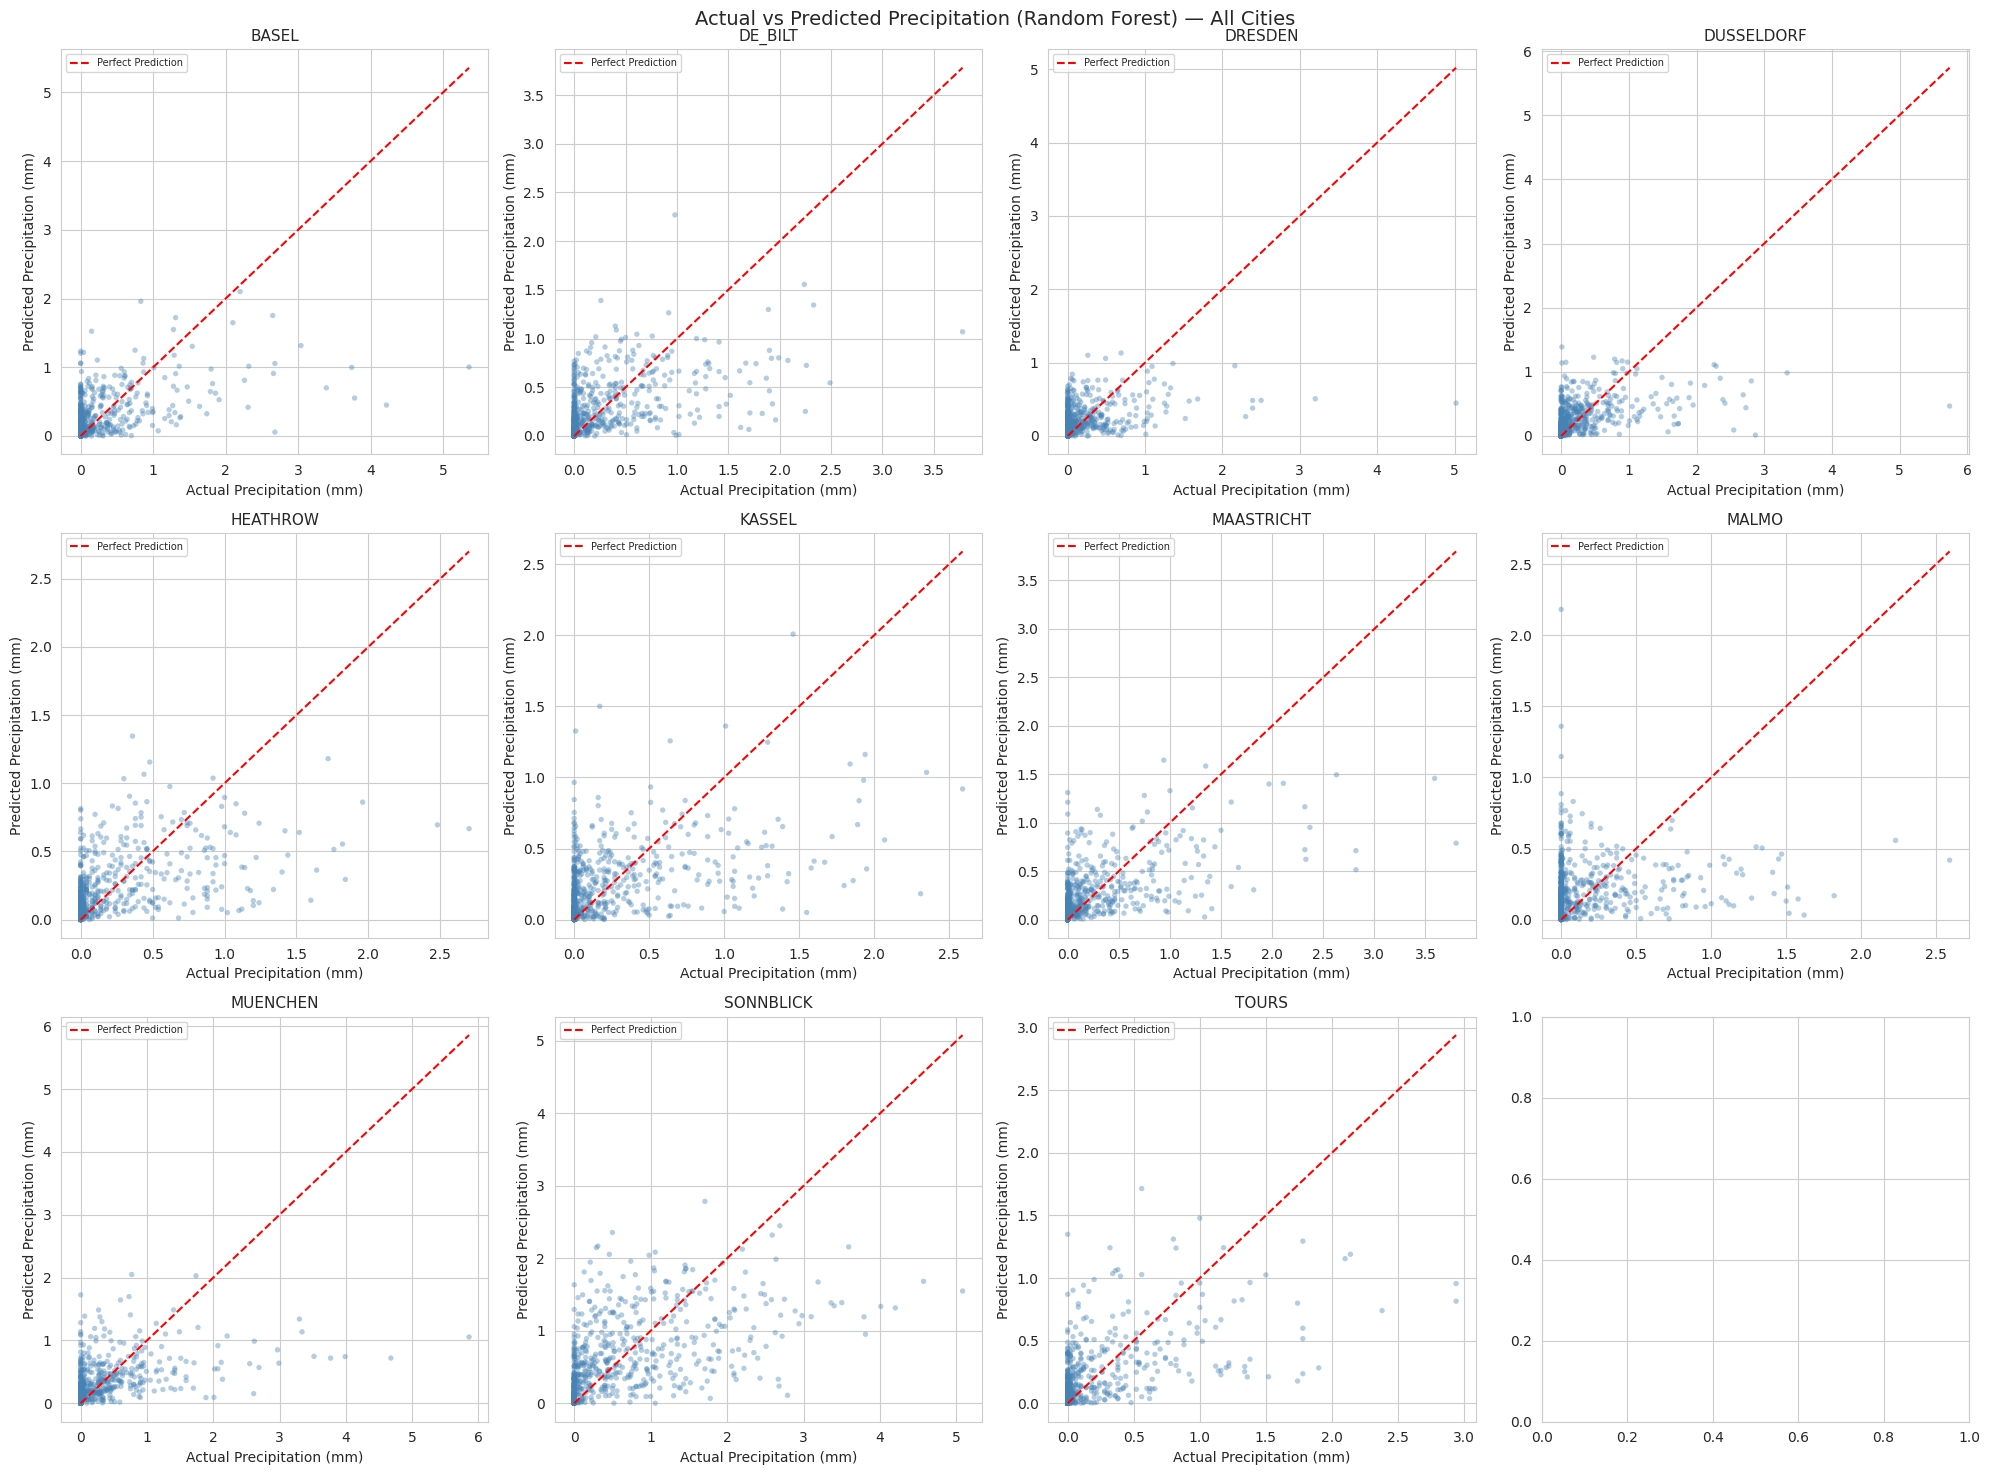

In [ ]:
# Actual vs Predicted Plots for All Cities

# will plot actual vs predicted for the best model per city
# Using Random Forest as it wins most cities

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, city in enumerate(cities_with_precip):
    if city == 'avg':
        continue

    X, y, col_names = get_city_data(df, city, city_features)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    axes[i].scatter(y_test, y_pred, alpha=0.4, color='steelblue',
                    edgecolors='none', s=15)

    max_val = max(y_test.max(), y_pred.max())
    axes[i].plot([0, max_val], [0, max_val], color='red',
                 linewidth=1.5, linestyle='--', label='Perfect Prediction')

    axes[i].set_title(city, fontsize=11)
    axes[i].set_xlabel('Actual Precipitation (mm)')
    axes[i].set_ylabel('Predicted Precipitation (mm)')
    axes[i].legend(fontsize=7)

for j in range(len(cities_with_precip), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Actual vs Predicted Precipitation (Random Forest) — All Cities',
             fontsize=14)
plt.tight_layout()
plt.show()

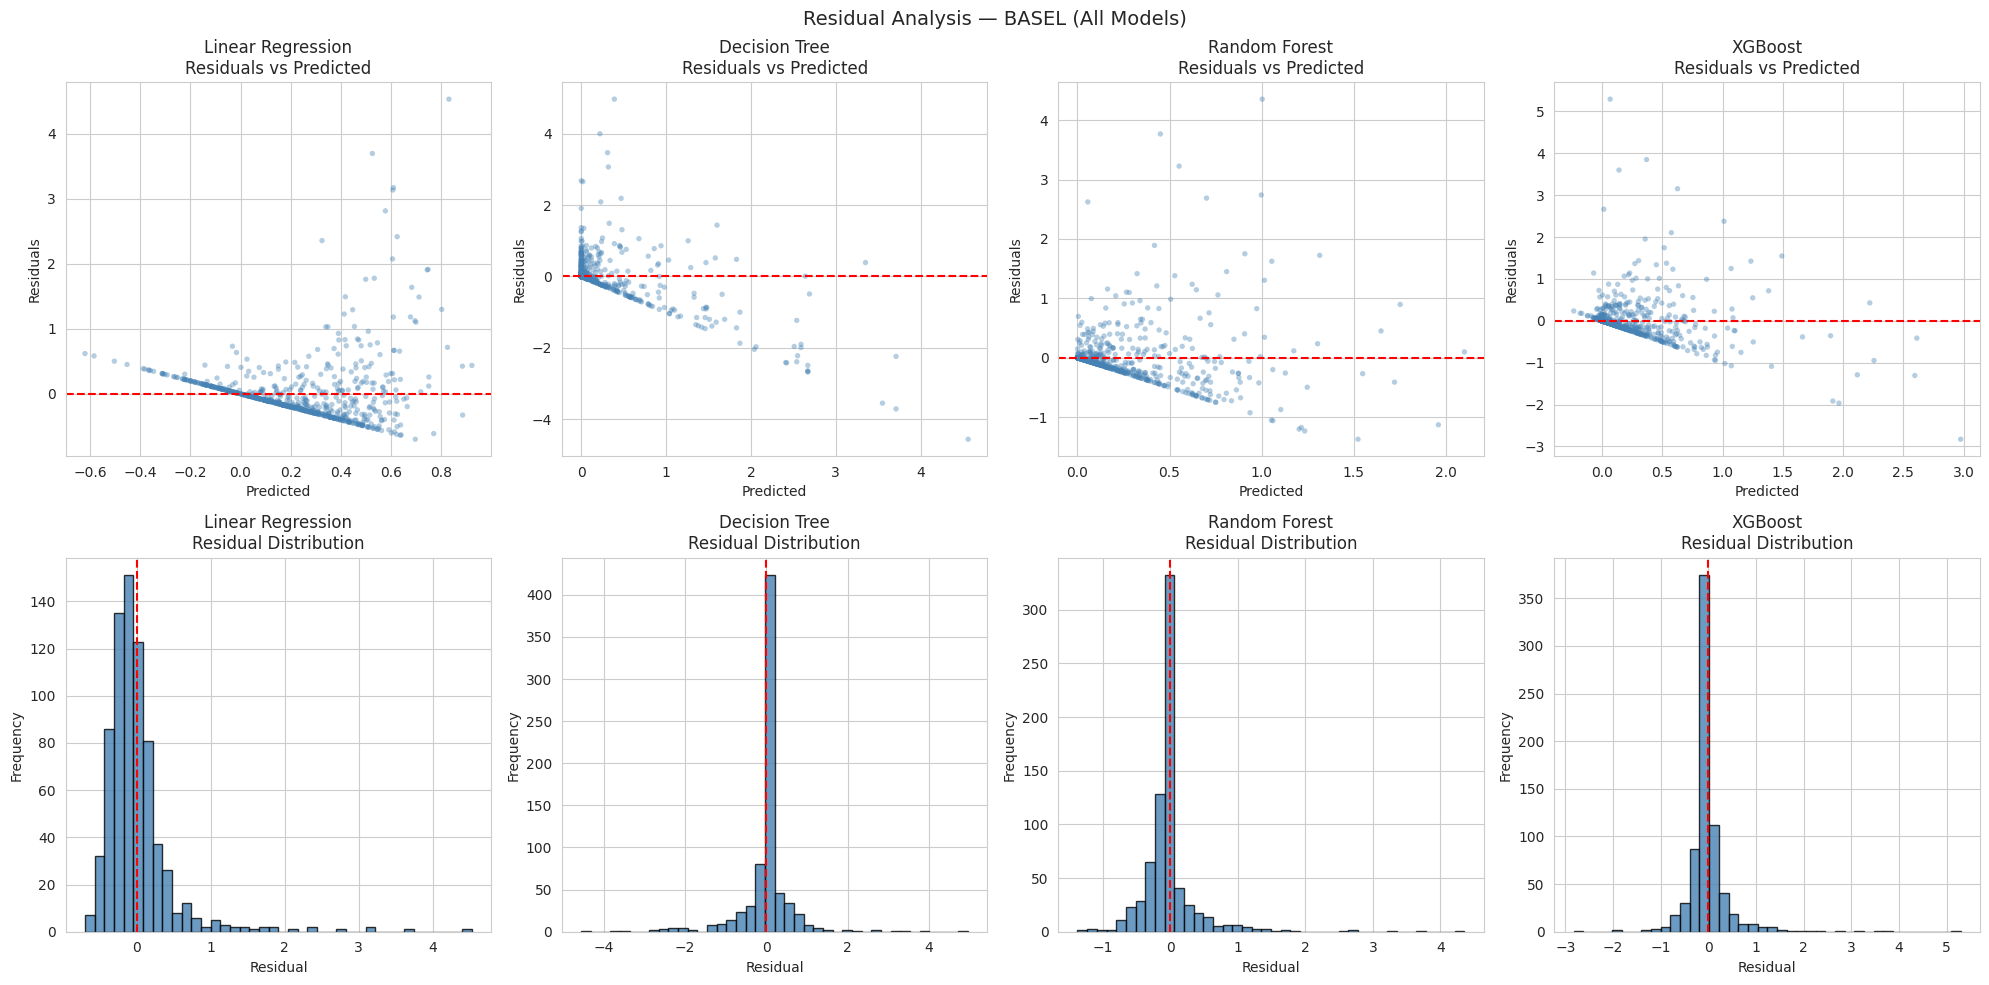

In [ ]:
# Residual Analysis for All Models (Using BASEL as representative)

X, y, col_names = get_city_data(df, 'BASEL', city_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model_objects = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree'     : DecisionTreeRegressor(random_state=42),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost'           : XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

predictions = {}

for name, model in model_objects.items():
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    predictions[name] = y_pred

# Plot residuals for each model
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, (name, y_pred) in enumerate(predictions.items()):
    residuals = y_test.values - y_pred

    # Residual scatter
    axes[0][i].scatter(y_pred, residuals, alpha=0.4,
                       color='steelblue', edgecolors='none', s=15)
    axes[0][i].axhline(0, color='red', linewidth=1.5, linestyle='--')
    axes[0][i].set_title(f'{name}\nResiduals vs Predicted')
    axes[0][i].set_xlabel('Predicted')
    axes[0][i].set_ylabel('Residuals')

    # Residual distribution
    axes[1][i].hist(residuals, bins=40, color='steelblue',
                    edgecolor='black', alpha=0.8)
    axes[1][i].axvline(0, color='red', linewidth=1.5, linestyle='--')
    axes[1][i].set_title(f'{name}\nResidual Distribution')
    axes[1][i].set_xlabel('Residual')
    axes[1][i].set_ylabel('Frequency')

plt.suptitle('Residual Analysis — BASEL (All Models)', fontsize=14)
plt.tight_layout()
plt.show()

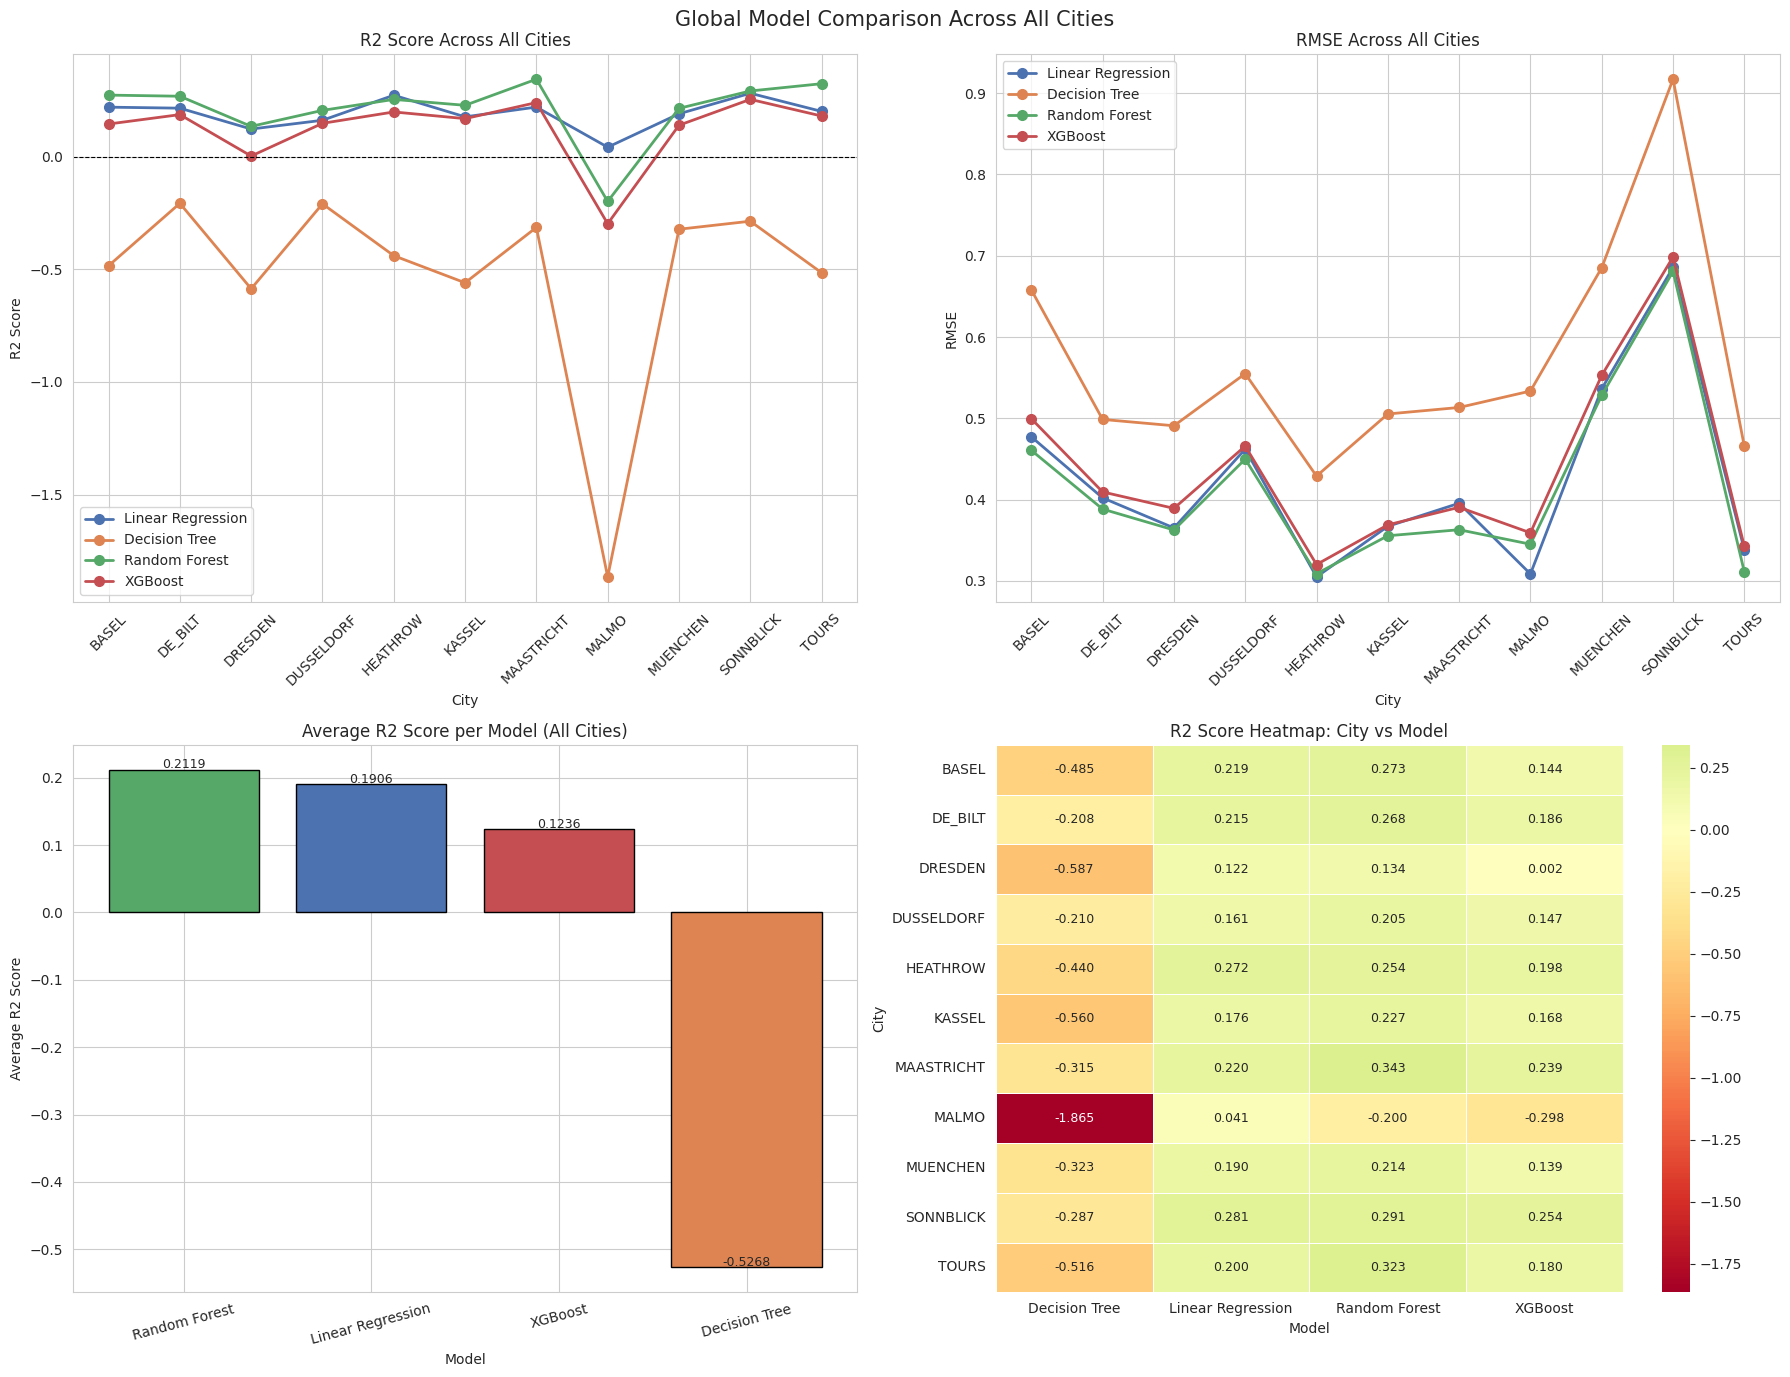

In [ ]:
# Final Global Comparison Visualisation

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

model_colors = {
    'Linear Regression' : '#4C72B0',
    'Decision Tree'     : '#DD8452',
    'Random Forest'     : '#55A868',
    'XGBoost'           : '#C44E52'
}

# Plot 1: R2 Score per city per model (line chart)
for model_name, color in model_colors.items():
    subset = results_df[results_df['Model'] == model_name]
    axes[0][0].plot(subset['City'], subset['R2_Score'],
                    marker='o', label=model_name,
                    color=color, linewidth=2, markersize=7)

axes[0][0].set_title('R2 Score Across All Cities')
axes[0][0].set_xlabel('City')
axes[0][0].set_ylabel('R2 Score')
axes[0][0].tick_params(axis='x', rotation=45)
axes[0][0].legend()
axes[0][0].axhline(0, color='black', linewidth=0.8, linestyle='--')

# Plot 2: RMSE per city per model
for model_name, color in model_colors.items():
    subset = results_df[results_df['Model'] == model_name]
    axes[0][1].plot(subset['City'], subset['RMSE'],
                    marker='o', label=model_name,
                    color=color, linewidth=2, markersize=7)

axes[0][1].set_title('RMSE Across All Cities')
axes[0][1].set_xlabel('City')
axes[0][1].set_ylabel('RMSE')
axes[0][1].tick_params(axis='x', rotation=45)
axes[0][1].legend()

# Plot 3: Average R2 per model (bar chart)
avg_r2 = results_df.groupby('Model')['R2_Score'].mean().sort_values(ascending=False)
bars = axes[1][0].bar(avg_r2.index, avg_r2.values,
                       color=[model_colors[m] for m in avg_r2.index],
                       edgecolor='black')
axes[1][0].set_title('Average R2 Score per Model (All Cities)')
axes[1][0].set_xlabel('Model')
axes[1][0].set_ylabel('Average R2 Score')
axes[1][0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, avg_r2.values):
    axes[1][0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.002,
                    str(round(val, 4)), ha='center', fontsize=9)

# Plot 4: R2 Heatmap
pivot_r2 = results_df.pivot(index='City', columns='Model', values='R2_Score')
sns.heatmap(pivot_r2, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, linewidths=0.5,
            annot_kws={'size': 9}, ax=axes[1][1])
axes[1][1].set_title('R2 Score Heatmap: City vs Model')
axes[1][1].set_xlabel('Model')
axes[1][1].set_ylabel('City')

plt.suptitle('Global Model Comparison Across All Cities', fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:
# Advanced Feature Engineering

def engineer_features(dataframe, city, city_feat_dict):
    """
    Builds an enriched feature set for a given city including:
    - Original meteorological features
    - Lag features (1-day, 3-day, 7-day)
    - Rolling statistics (3-day and 7-day mean)
    - Seasonal encoding (sine and cosine of month and day of year)
    - Cross-city average precipitation as external feature
    - Log-transformed target
    """

    df_city = dataframe.copy()

    # Get base features for city
    available = city_feat_dict[city]
    feature_names = [f for f in available if f != 'precipitation']
    col_names     = [f"{city}_{f}" for f in feature_names]
    target_col    = f"{city}_precipitation"

    df_eng = df_city[['DATE', 'MONTH'] + col_names + [target_col]].copy()

    # Sort by date to ensure correct lag computation
    df_eng = df_eng.sort_values('DATE').reset_index(drop=True)

    # Seasonal encoding using sine and cosine transforms
    # This captures the cyclical nature of months properly
    df_eng['month_sin'] = np.sin(2 * np.pi * df_eng['MONTH'] / 12)
    df_eng['month_cos'] = np.cos(2 * np.pi * df_eng['MONTH'] / 12)

    # Day of year from DATE column
    df_eng['DATE_dt']   = pd.to_datetime(df_eng['DATE'], format='%Y%m%d')
    df_eng['day_of_year'] = df_eng['DATE_dt'].dt.dayofyear
    df_eng['doy_sin']   = np.sin(2 * np.pi * df_eng['day_of_year'] / 365)
    df_eng['doy_cos']   = np.cos(2 * np.pi * df_eng['day_of_year'] / 365)

    # Lag features on target (previous days rainfall)
    df_eng['precip_lag1'] = df_eng[target_col].shift(1)
    df_eng['precip_lag2'] = df_eng[target_col].shift(2)
    df_eng['precip_lag3'] = df_eng[target_col].shift(3)
    df_eng['precip_lag7'] = df_eng[target_col].shift(7)

    # Rolling statistics on target
    df_eng['precip_roll3_mean'] = df_eng[target_col].shift(1).rolling(3).mean()
    df_eng['precip_roll7_mean'] = df_eng[target_col].shift(1).rolling(7).mean()
    df_eng['precip_roll3_max']  = df_eng[target_col].shift(1).rolling(3).max()
    df_eng['precip_roll7_std']  = df_eng[target_col].shift(1).rolling(7).std()

    # Cross-city average precipitation (all other cities combined)
    other_precip_cols = [
        f"{c}_precipitation" for c in city_feat_dict.keys()
        if c != city and f"{c}_precipitation" in dataframe.columns
    ]
    if len(other_precip_cols) > 0:
        df_eng['cross_city_precip_mean'] = dataframe[other_precip_cols].mean(axis=1).values
        df_eng['cross_city_precip_max']  = dataframe[other_precip_cols].max(axis=1).values

    # Lag features on key meteorological variables if available
    if f"{city}_humidity" in col_names:
        df_eng['humidity_lag1'] = df_eng[f"{city}_humidity"].shift(1)

    if f"{city}_pressure" in col_names:
        df_eng['pressure_lag1']  = df_eng[f"{city}_pressure"].shift(1)
        df_eng['pressure_diff1'] = df_eng[f"{city}_pressure"].diff(1)

    if f"{city}_cloud_cover" in col_names:
        df_eng['cloud_lag1'] = df_eng[f"{city}_cloud_cover"].shift(1)

    # Drop rows with NaN from lag operations
    df_eng = df_eng.dropna().reset_index(drop=True)

    # Drop helper columns
    df_eng = df_eng.drop(columns=['DATE', 'MONTH', 'DATE_dt', 'day_of_year'])

    # Separate features and target
    X = df_eng.drop(columns=[target_col])
    y = df_eng[target_col]

    # Log transform target: log1p handles zero values safely
    y_log = np.log1p(y)

    return X, y, y_log, X.columns.tolist()


print("Feature engineering function defined.")
print()

# Test on BASEL to see new feature set
X_test_eng, y_test_eng, y_log_test, feat_names = engineer_features(
    df, 'BASEL', city_features
)

print(f"Original feature count : 9")
print(f"Engineered feature count: {X_test_eng.shape[1]}")
print()
print("New features added:")
original_feats = [
    'BASEL_cloud_cover','BASEL_humidity','BASEL_pressure',
    'BASEL_global_radiation','BASEL_sunshine',
    'BASEL_temp_mean','BASEL_temp_min','BASEL_temp_max'
]
new_feats = [f for f in feat_names if f not in original_feats]
for f in new_feats:
    print(f"  {f}")

print()
print(f"Dataset size after lag dropna: {X_test_eng.shape[0]} rows")

Feature engineering function defined.

Original feature count : 9
Engineered feature count: 26

New features added:
  month_sin
  month_cos
  doy_sin
  doy_cos
  precip_lag1
  precip_lag2
  precip_lag3
  precip_lag7
  precip_roll3_mean
  precip_roll7_mean
  precip_roll3_max
  precip_roll7_std
  cross_city_precip_mean
  cross_city_precip_max
  humidity_lag1
  pressure_lag1
  pressure_diff1
  cloud_lag1

Dataset size after lag dropna: 3647 rows


In [ ]:
# Advanced Model Definitions

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    VotingRegressor,
    StackingRegressor
)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score


def build_advanced_models():
    """
    Returns a dictionary of advanced models including:
    - Tuned Random Forest
    - Tuned XGBoost
    - Gradient Boosting
    - Voting Regressor (ensemble)
    - Stacking Regressor (meta-learning)
    """

    rf_tuned = RandomForestRegressor(
        n_estimators    = 300,
        max_depth       = 10,
        min_samples_split = 5,
        min_samples_leaf  = 2,
        max_features    = 'sqrt',
        random_state    = 42,
        n_jobs          = -1
    )

    xgb_tuned = XGBRegressor(
        n_estimators    = 300,
        max_depth       = 5,
        learning_rate   = 0.05,
        subsample       = 0.8,
        colsample_bytree= 0.8,
        reg_alpha       = 0.1,
        reg_lambda      = 1.0,
        random_state    = 42,
        verbosity       = 0
    )

    gb_model = GradientBoostingRegressor(
        n_estimators    = 300,
        max_depth       = 4,
        learning_rate   = 0.05,
        subsample       = 0.8,
        random_state    = 42
    )

    # Voting Regressor: combines predictions by averaging
    voting_model = VotingRegressor(
        estimators = [
            ('rf',  RandomForestRegressor(
                        n_estimators=200, max_depth=8,
                        random_state=42, n_jobs=-1)),
            ('xgb', XGBRegressor(
                        n_estimators=200, max_depth=4,
                        learning_rate=0.05, random_state=42,
                        verbosity=0)),
            ('gb',  GradientBoostingRegressor(
                        n_estimators=200, max_depth=4,
                        learning_rate=0.05, random_state=42))
        ]
    )

    # Stacking Regressor: base models feed into a meta-learner (Ridge)
    stacking_model = StackingRegressor(
        estimators = [
            ('rf',  RandomForestRegressor(
                        n_estimators=200, max_depth=8,
                        random_state=42, n_jobs=-1)),
            ('xgb', XGBRegressor(
                        n_estimators=200, max_depth=4,
                        learning_rate=0.05, random_state=42,
                        verbosity=0)),
            ('gb',  GradientBoostingRegressor(
                        n_estimators=200, max_depth=4,
                        learning_rate=0.05, random_state=42)),
            ('dt',  DecisionTreeRegressor(
                        max_depth=5, random_state=42))
        ],
        final_estimator = Ridge(alpha=1.0),
        cv              = 5,
        n_jobs          = -1
    )

    models = {
        'Random Forest (Tuned)'  : rf_tuned,
        'XGBoost (Tuned)'        : xgb_tuned,
        'Gradient Boosting'      : gb_model,
        'Voting Ensemble'        : voting_model,
        'Stacking Ensemble'      : stacking_model
    }

    return models


print("Advanced models defined:")
for name in build_advanced_models().keys():
    print(f"  {name}")

Advanced models defined:
  Random Forest (Tuned)
  XGBoost (Tuned)
  Gradient Boosting
  Voting Ensemble
  Stacking Ensemble


In [ ]:
# Advanced Pipeline Runner Across All Cities

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def run_advanced_pipeline(dataframe, city, city_feat_dict):
    """
    Full advanced pipeline for one city:
    - Engineer features
    - Split data
    - Scale features
    - Train all advanced models on log-transformed target
    - Evaluate and return results
    """

    X, y, y_log, feat_names = engineer_features(
        dataframe, city, city_feat_dict
    )

    X_train, X_test, y_train_log, y_test_log = train_test_split(
        X, y_log, test_size=0.2, random_state=42
    )

    # Keep original y_test for inverse transform evaluation
    _, _, y_train_orig, y_test_orig = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler        = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    X_train_scaled = pd.DataFrame(
        X_train_scaled, columns=feat_names, index=X_train.index
    )
    X_test_scaled  = pd.DataFrame(
        X_test_scaled, columns=feat_names, index=X_test.index
    )

    models  = build_advanced_models()
    results = []

    for model_name, model in models.items():
        model.fit(X_train_scaled, y_train_log)
        y_pred_log = model.predict(X_test_scaled)

        # Inverse log transform for real-scale evaluation
        y_pred_orig = np.expm1(y_pred_log)
        y_pred_orig = np.clip(y_pred_orig, 0, None)

        mae  = mean_absolute_error(y_test_orig, y_pred_orig)
        rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
        r2   = r2_score(y_test_orig, y_pred_orig)

        results.append({
            'City'     : city,
            'Model'    : model_name,
            'MAE'      : round(mae,  4),
            'RMSE'     : round(rmse, 4),
            'R2_Score' : round(r2,   4)
        })

    return results, models, X_test_scaled, y_test_orig, scaler


# Run for all cities
print("Running advanced pipeline for all cities...")
print()

advanced_results  = []
advanced_models   = {}
advanced_test_data = {}

for city in cities_with_precip:
    if city == 'avg':
        continue

    results, models, X_test_s, y_test_o, scaler = run_advanced_pipeline(
        df, city, city_features
    )

    advanced_results.extend(results)
    advanced_models[city]    = models
    advanced_test_data[city] = {
        'X_test' : X_test_s,
        'y_test' : y_test_o
    }

    best = max(results, key=lambda x: x['R2_Score'])
    print(f"  {city:15s} done | Best: {best['Model']:25s} | R2: {best['R2_Score']}")

advanced_df = pd.DataFrame(advanced_results)

print()
print("Advanced Results Table:")
display(advanced_df)

Running advanced pipeline for all cities...

  BASEL           done | Best: XGBoost (Tuned)           | R2: 0.3124
  DE_BILT         done | Best: Gradient Boosting         | R2: 0.4335
  DRESDEN         done | Best: XGBoost (Tuned)           | R2: 0.348
  DUSSELDORF      done | Best: XGBoost (Tuned)           | R2: 0.4683
  HEATHROW        done | Best: Voting Ensemble           | R2: 0.3147
  KASSEL          done | Best: Gradient Boosting         | R2: 0.3287
  MAASTRICHT      done | Best: XGBoost (Tuned)           | R2: 0.5401
  MALMO           done | Best: Voting Ensemble           | R2: 0.0935
  MUENCHEN        done | Best: Gradient Boosting         | R2: 0.2875
  SONNBLICK       done | Best: XGBoost (Tuned)           | R2: 0.4312
  TOURS           done | Best: Gradient Boosting         | R2: 0.4436

Advanced Results Table:


,City,Model,MAE,RMSE,R2_Score
0,BASEL,Random Forest (Tuned),0.2478,0.5874,0.2521
1,BASEL,XGBoost (Tuned),0.2338,0.5632,0.3124
2,BASEL,Gradient Boosting,0.2346,0.5669,0.3033
3,BASEL,Voting Ensemble,0.2339,0.5688,0.2988
4,BASEL,Stacking Ensemble,0.2331,0.5679,0.3009
5,DE_BILT,Random Forest (Tuned),0.1818,0.3322,0.4041
6,DE_BILT,XGBoost (Tuned),0.1708,0.3249,0.4300
7,DE_BILT,Gradient Boosting,0.1718,0.3239,0.4335
8,DE_BILT,Voting Ensemble,0.1734,0.3267,0.4237
9,DE_BILT,Stacking Ensemble,0.1714,0.3265,0.4244


Basic Pipeline - Average R2 per Model:
Model
Random Forest        0.2119
Linear Regression    0.1906
XGBoost              0.1236
Decision Tree       -0.5268

Advanced Pipeline - Average R2 per Model:
Model
XGBoost (Tuned)          0.3580
Gradient Boosting        0.3569
Voting Ensemble          0.3530
Stacking Ensemble        0.3487
Random Forest (Tuned)    0.3231

Best R2 in Basic Pipeline   : 0.3431 -> MAASTRICHT Random Forest
Best R2 in Advanced Pipeline: 0.5401 -> MAASTRICHT XGBoost (Tuned)


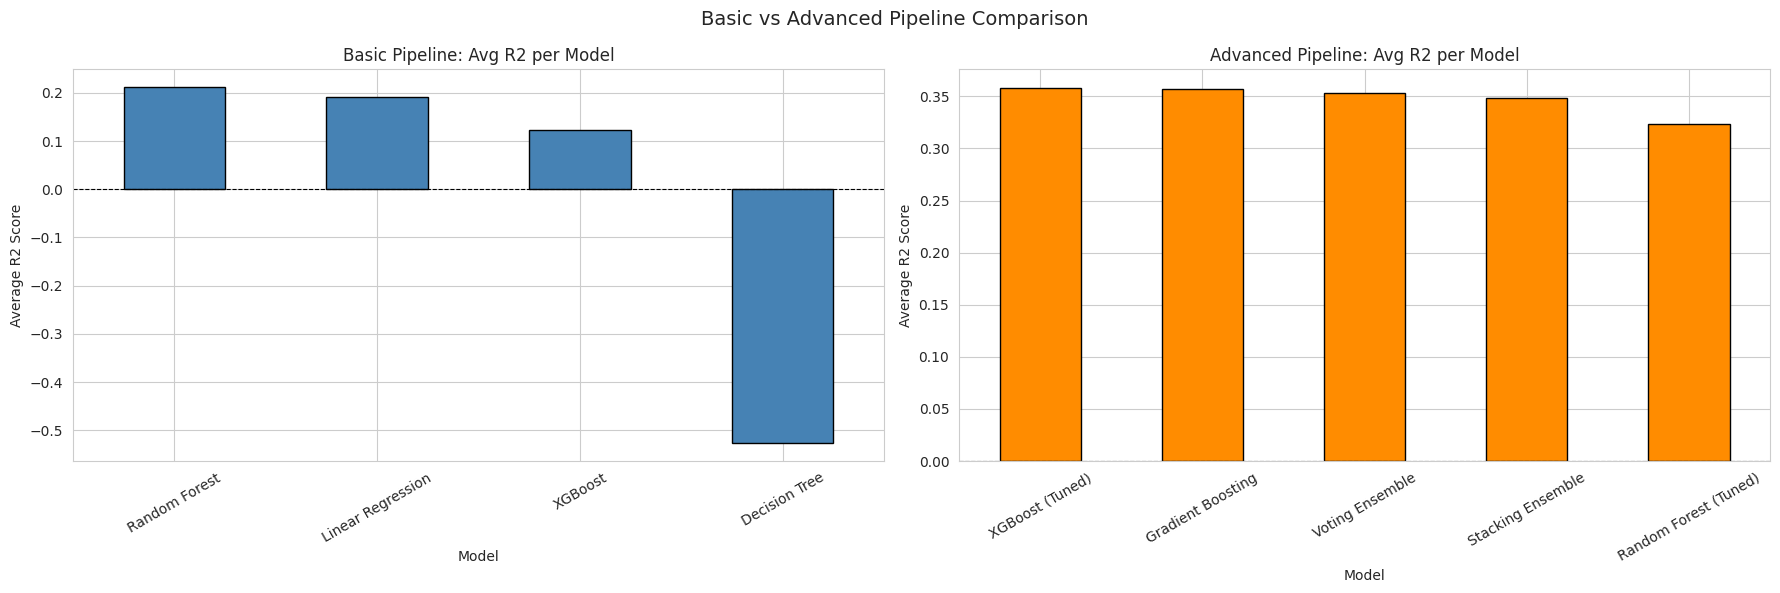

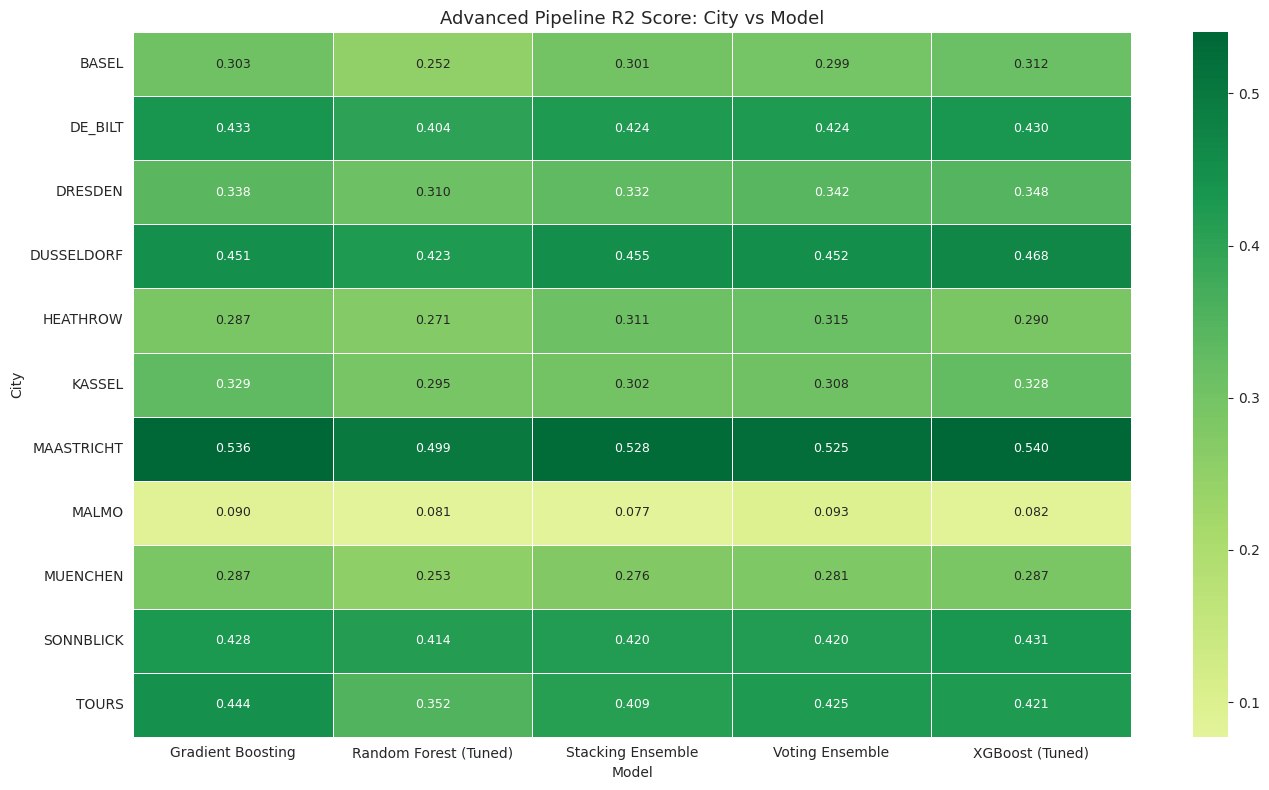

In [ ]:
# Compare Basic vs Advanced Results

# Average R2 per model - basic pipeline
basic_avg = results_df.groupby('Model')['R2_Score'].mean().round(4)
basic_avg.name = 'Basic Pipeline'

# Average R2 per model - advanced pipeline
adv_avg = advanced_df.groupby('Model')['R2_Score'].mean().round(4)
adv_avg.name = 'Advanced Pipeline'

print("Basic Pipeline - Average R2 per Model:")
print(basic_avg.sort_values(ascending=False).to_string())
print()
print("Advanced Pipeline - Average R2 per Model:")
print(adv_avg.sort_values(ascending=False).to_string())

# Overall best R2 comparison
print()
print("Best R2 in Basic Pipeline   :", results_df['R2_Score'].max(),
      "->", results_df.loc[results_df['R2_Score'].idxmax(), 'City'],
      results_df.loc[results_df['R2_Score'].idxmax(), 'Model'])

print("Best R2 in Advanced Pipeline:", advanced_df['R2_Score'].max(),
      "->", advanced_df.loc[advanced_df['R2_Score'].idxmax(), 'City'],
      advanced_df.loc[advanced_df['R2_Score'].idxmax(), 'Model'])

# Side by side bar chart
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

basic_avg.sort_values(ascending=False).plot(
    kind='bar', ax=axes[0], color='steelblue',
    edgecolor='black'
)
axes[0].set_title('Basic Pipeline: Avg R2 per Model')
axes[0].set_ylabel('Average R2 Score')
axes[0].set_xlabel('Model')
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

adv_avg.sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='darkorange',
    edgecolor='black'
)
axes[1].set_title('Advanced Pipeline: Avg R2 per Model')
axes[1].set_ylabel('Average R2 Score')
axes[1].set_xlabel('Model')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('Basic vs Advanced Pipeline Comparison', fontsize=14)
plt.tight_layout()
plt.show()

# Heatmap for advanced results
pivot_adv = advanced_df.pivot(index='City', columns='Model', values='R2_Score')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_adv, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Advanced Pipeline R2 Score: City vs Model', fontsize=13)
plt.tight_layout()
plt.show()

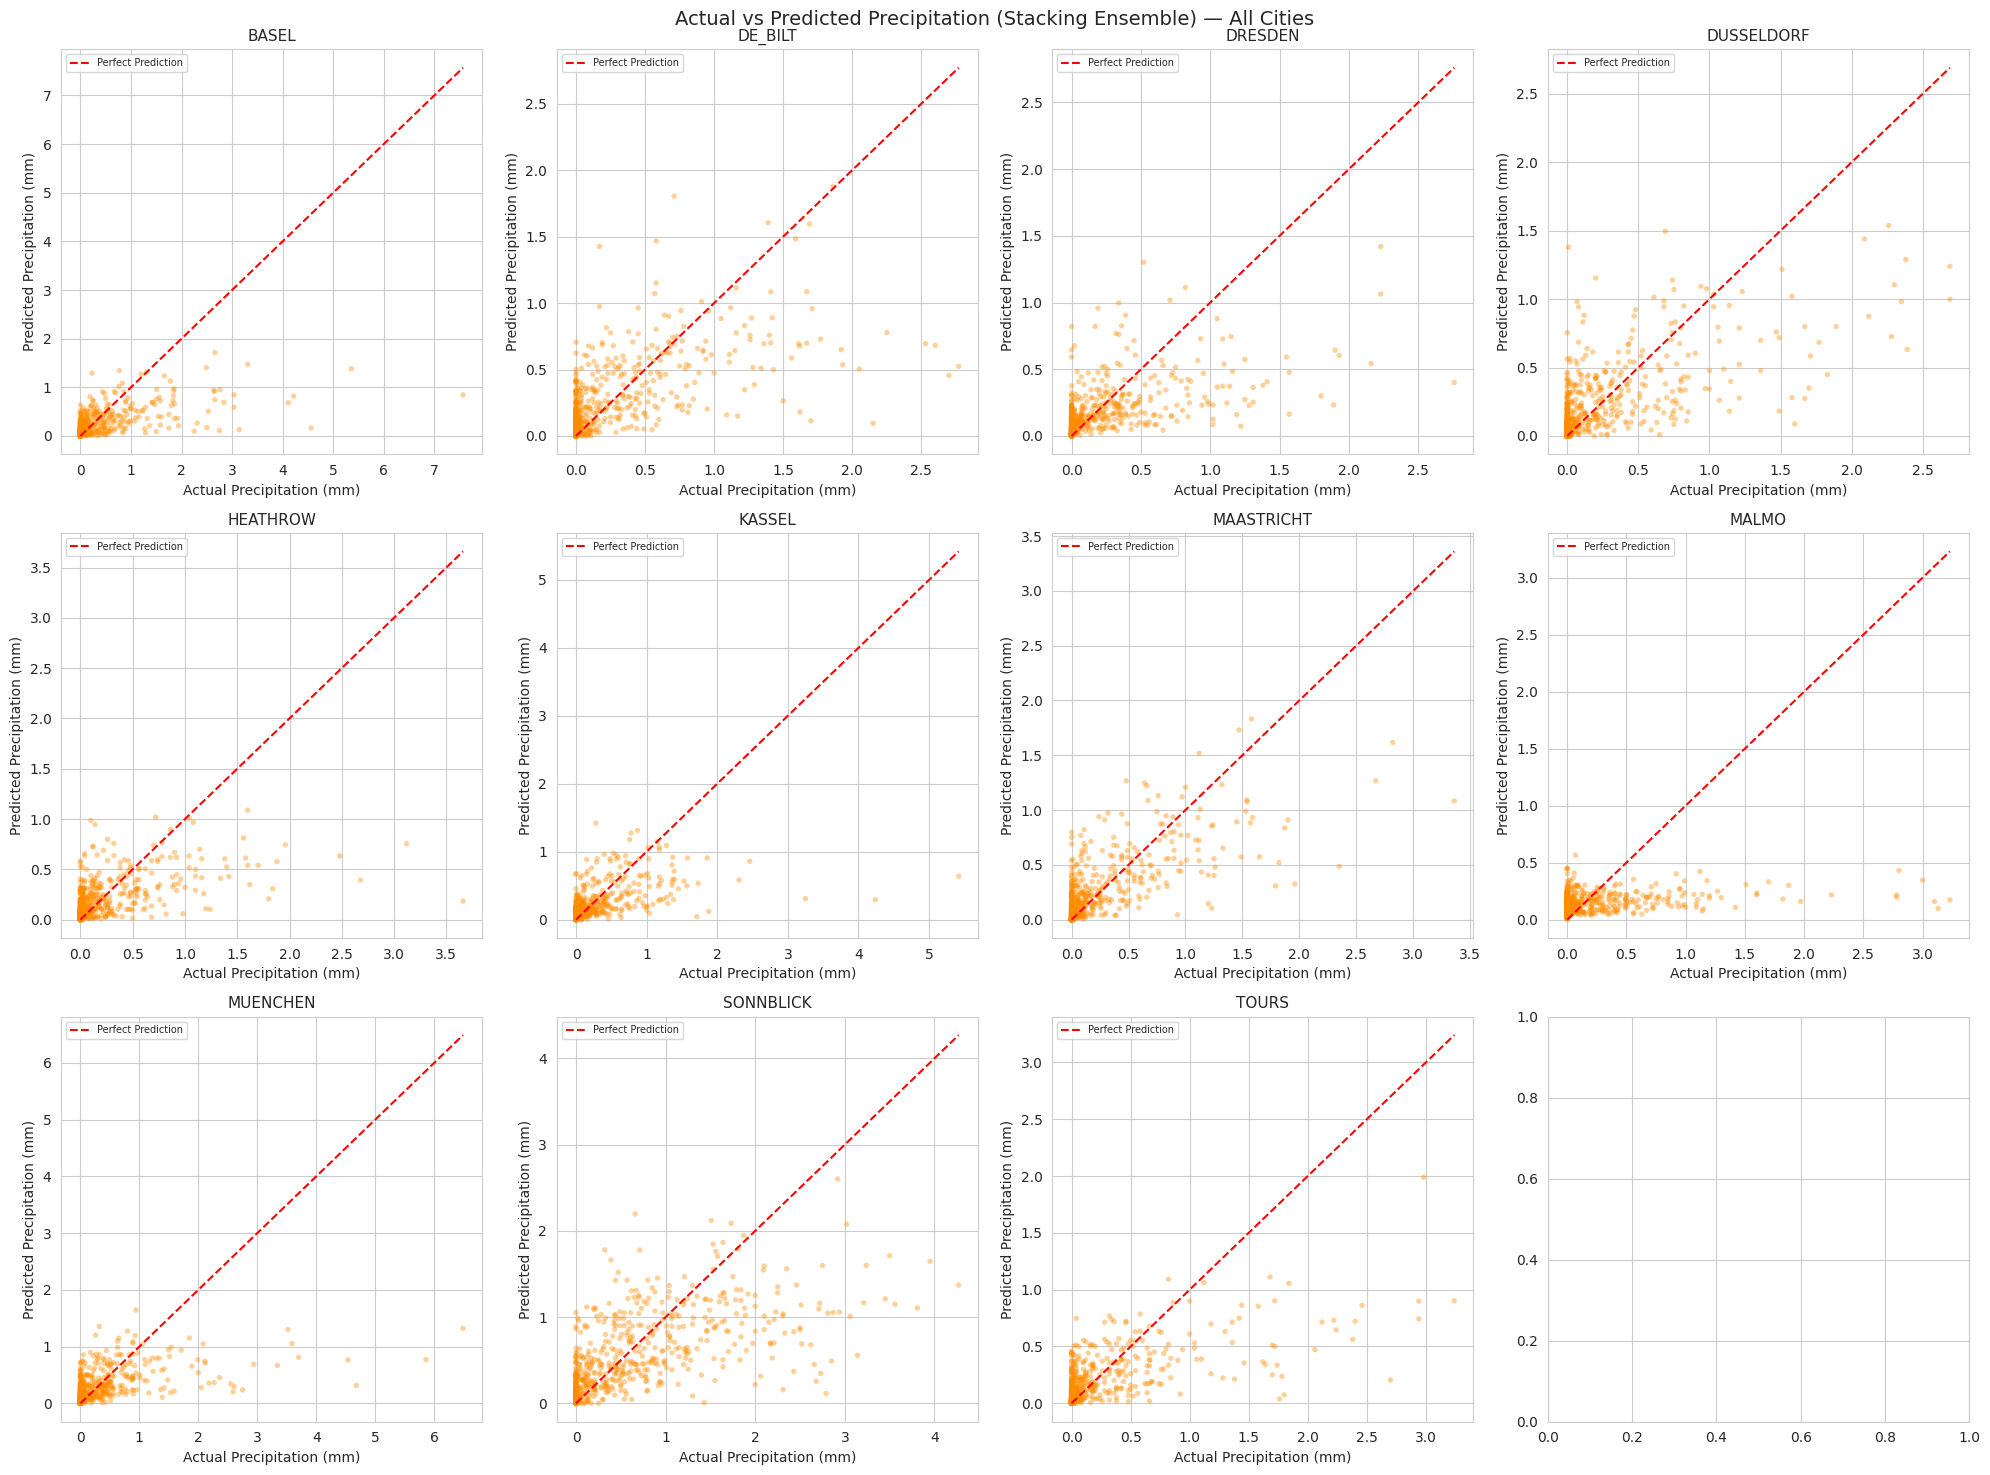

In [ ]:
# Actual vs Predicted Plots for All Cities (Advanced Models)

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, city in enumerate(cities_with_precip):
    if city == 'avg':
        continue

    X, y, y_log, feat_names = engineer_features(df, city, city_features)

    X_train, X_test, y_train_log, y_test_log = train_test_split(
        X, y_log, test_size=0.2, random_state=42
    )
    _, _, y_train_orig, y_test_orig = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    X_train_scaled = pd.DataFrame(
        X_train_scaled, columns=feat_names, index=X_train.index
    )
    X_test_scaled  = pd.DataFrame(
        X_test_scaled, columns=feat_names, index=X_test.index
    )

    # Use best performing advanced model: Stacking Ensemble
    model = advanced_models[city]['Stacking Ensemble']

    y_pred_log  = model.predict(X_test_scaled)
    y_pred_orig = np.clip(np.expm1(y_pred_log), 0, None)

    max_val = max(y_test_orig.max(), y_pred_orig.max())

    axes[i].scatter(
        y_test_orig, y_pred_orig,
        alpha=0.4, color='darkorange',
        edgecolors='none', s=15
    )
    axes[i].plot(
        [0, max_val], [0, max_val],
        color='red', linewidth=1.5,
        linestyle='--', label='Perfect Prediction'
    )
    axes[i].set_title(city, fontsize=11)
    axes[i].set_xlabel('Actual Precipitation (mm)')
    axes[i].set_ylabel('Predicted Precipitation (mm)')
    axes[i].legend(fontsize=7)

for j in range(len(cities_with_precip), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Actual vs Predicted Precipitation (Stacking Ensemble) — All Cities',
    fontsize=14
)
plt.tight_layout()
plt.show()

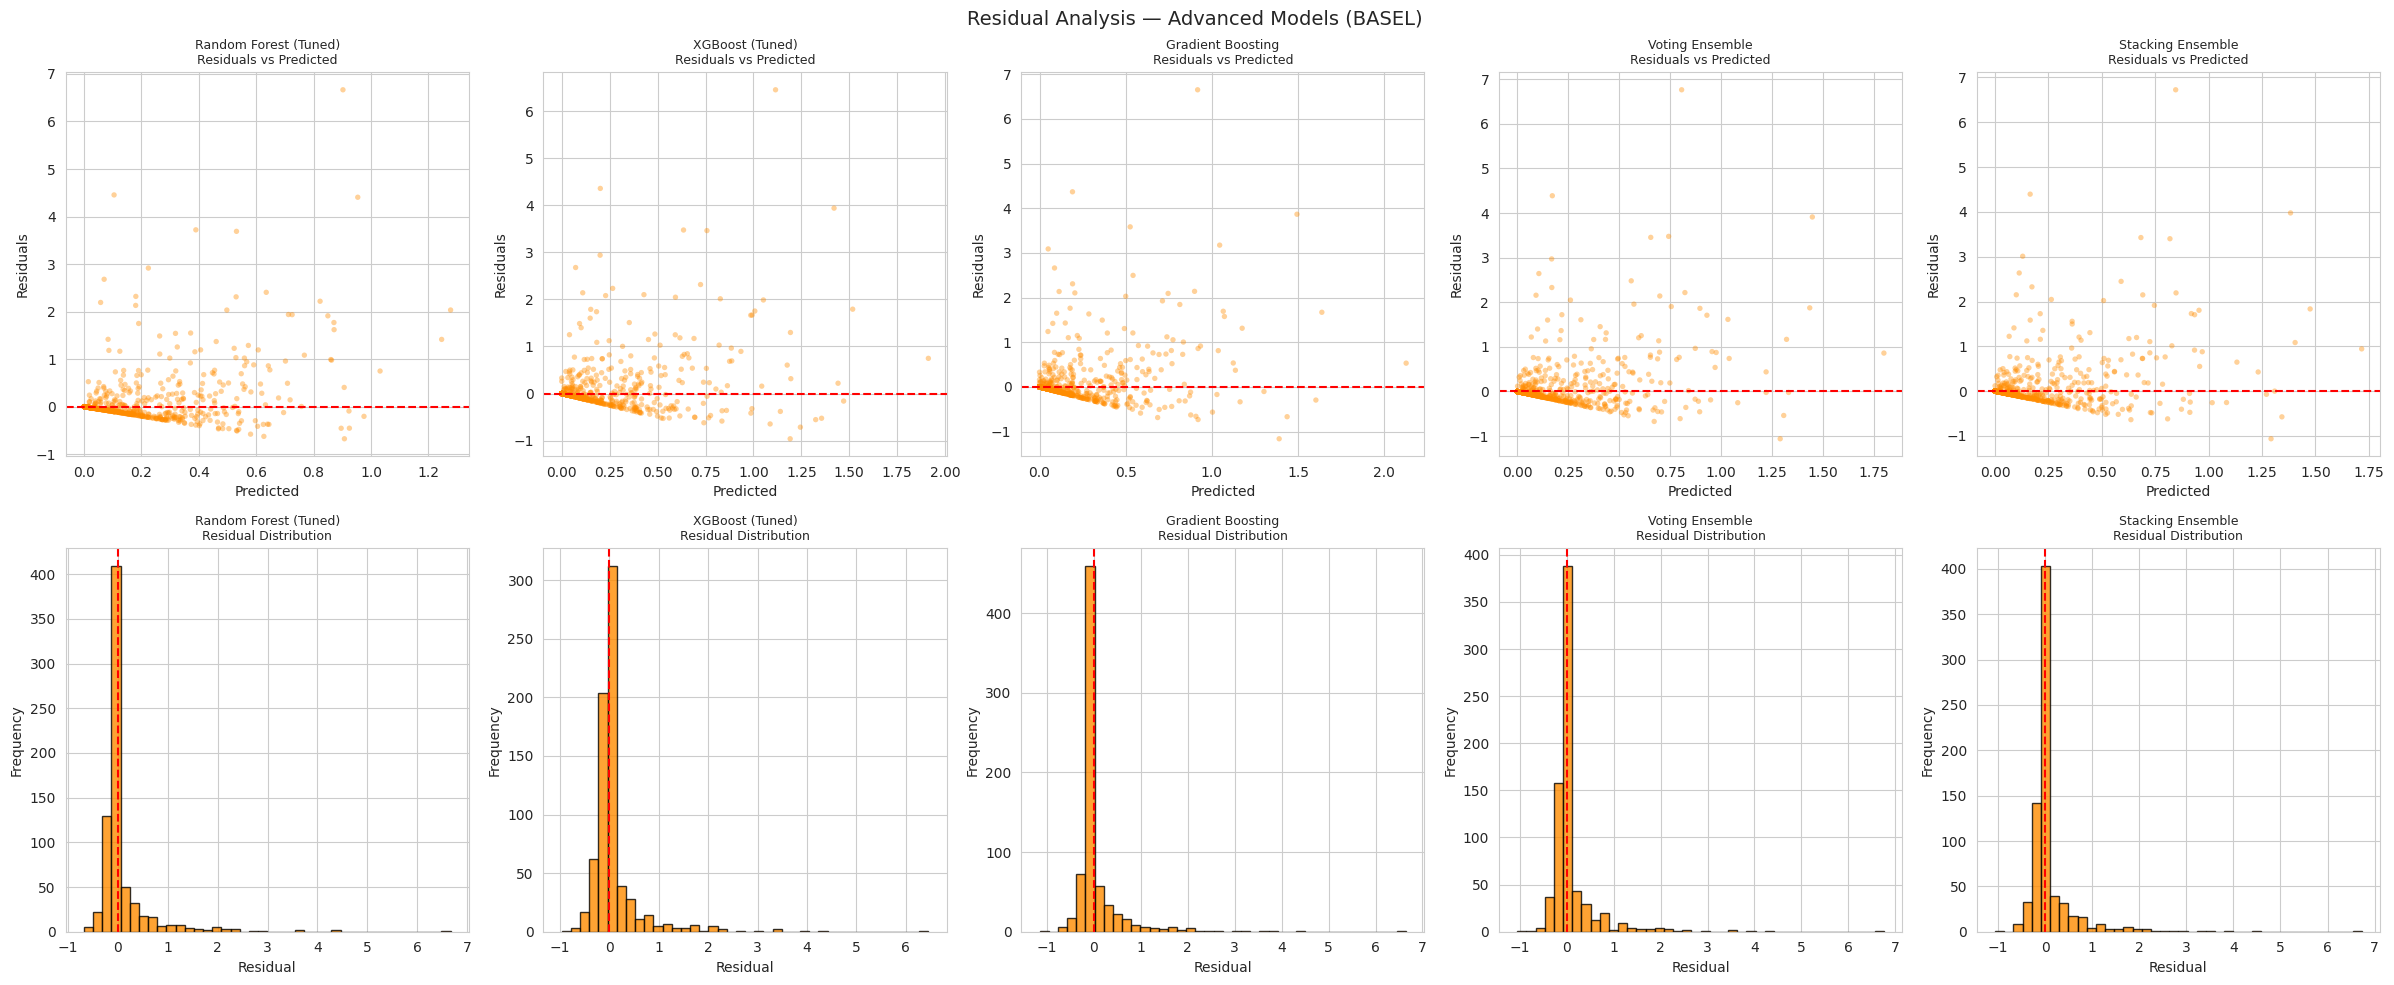

In [ ]:
# Residual Analysis — Advanced Models (BASEL as Representative City)

X, y, y_log, feat_names = engineer_features(df, 'BASEL', city_features)

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)
_, _, y_train_orig, y_test_orig = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled, columns=feat_names, index=X_train.index
)
X_test_scaled  = pd.DataFrame(
    X_test_scaled, columns=feat_names, index=X_test.index
)

model_names = list(advanced_models['BASEL'].keys())
predictions = {}

for name in model_names:
    model       = advanced_models['BASEL'][name]
    y_pred_log  = model.predict(X_test_scaled)
    y_pred_orig = np.clip(np.expm1(y_pred_log), 0, None)
    predictions[name] = y_pred_orig

fig, axes = plt.subplots(2, 5, figsize=(24, 10))

for i, (name, y_pred) in enumerate(predictions.items()):
    residuals = y_test_orig.values - y_pred

    # Row 1: Residuals vs Predicted
    axes[0][i].scatter(
        y_pred, residuals,
        alpha=0.4, color='darkorange',
        edgecolors='none', s=15
    )
    axes[0][i].axhline(0, color='red', linewidth=1.5, linestyle='--')
    axes[0][i].set_title(f'{name}\nResiduals vs Predicted', fontsize=9)
    axes[0][i].set_xlabel('Predicted')
    axes[0][i].set_ylabel('Residuals')

    # Row 2: Residual Distribution
    axes[1][i].hist(
        residuals, bins=40,
        color='darkorange', edgecolor='black', alpha=0.8
    )
    axes[1][i].axvline(0, color='red', linewidth=1.5, linestyle='--')
    axes[1][i].set_title(f'{name}\nResidual Distribution', fontsize=9)
    axes[1][i].set_xlabel('Residual')
    axes[1][i].set_ylabel('Frequency')

plt.suptitle('Residual Analysis — Advanced Models (BASEL)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Evaluation Metrics Summary — Advanced Models

print("Advanced Models — Full Results Table:")
print()
display(advanced_df)

print()
print("Average Performance Per Model Across All Cities:")
print()
adv_avg_metrics = advanced_df.groupby('Model')[
    ['MAE','RMSE','R2_Score']
].mean().round(4).sort_values('R2_Score', ascending=False)
display(adv_avg_metrics)

print()
print("Best Model Per City (Advanced Pipeline):")
print()
best_adv_per_city = advanced_df.loc[
    advanced_df.groupby('City')['R2_Score'].idxmax()
].reset_index(drop=True)
display(best_adv_per_city[['City','Model','MAE','RMSE','R2_Score']])

print()
print("Win Count Per Model (Advanced Pipeline):")
print()
adv_win_count = best_adv_per_city['Model'].value_counts()
print(adv_win_count.to_string())

print()
print("Best Overall R2 (Advanced Pipeline):")
best_row = advanced_df.loc[advanced_df['R2_Score'].idxmax()]
print(f"  City  : {best_row['City']}")
print(f"  Model : {best_row['Model']}")
print(f"  R2    : {best_row['R2_Score']}")
print(f"  RMSE  : {best_row['RMSE']}")
print(f"  MAE   : {best_row['MAE']}")

Advanced Models — Full Results Table:



,City,Model,MAE,RMSE,R2_Score
0,BASEL,Random Forest (Tuned),0.2478,0.5874,0.2521
1,BASEL,XGBoost (Tuned),0.2338,0.5632,0.3124
2,BASEL,Gradient Boosting,0.2346,0.5669,0.3033
3,BASEL,Voting Ensemble,0.2339,0.5688,0.2988
4,BASEL,Stacking Ensemble,0.2331,0.5679,0.3009
5,DE_BILT,Random Forest (Tuned),0.1818,0.3322,0.4041
6,DE_BILT,XGBoost (Tuned),0.1708,0.3249,0.4300
7,DE_BILT,Gradient Boosting,0.1718,0.3239,0.4335
8,DE_BILT,Voting Ensemble,0.1734,0.3267,0.4237
9,DE_BILT,Stacking Ensemble,0.1714,0.3265,0.4244



Average Performance Per Model Across All Cities:



,MAE,RMSE,R2_Score
Model,,,
XGBoost (Tuned),0.1930,0.3911,0.3580
Gradient Boosting,0.1942,0.3916,0.3569
Voting Ensemble,0.1944,0.3932,0.3530
Stacking Ensemble,0.1945,0.3942,0.3487
Random Forest (Tuned),0.2022,0.4020,0.3231



Best Model Per City (Advanced Pipeline):



,City,Model,MAE,RMSE,R2_Score
0,BASEL,XGBoost (Tuned),0.2338,0.5632,0.3124
1,DE_BILT,Gradient Boosting,0.1718,0.3239,0.4335
2,DRESDEN,XGBoost (Tuned),0.1493,0.2832,0.3480
3,DUSSELDORF,XGBoost (Tuned),0.1650,0.3058,0.4683
4,HEATHROW,Voting Ensemble,0.1572,0.3156,0.3147
5,KASSEL,Gradient Boosting,0.1682,0.3689,0.3287
6,MAASTRICHT,XGBoost (Tuned),0.1427,0.2717,0.5401
7,MALMO,Voting Ensemble,0.1925,0.3942,0.0935
8,MUENCHEN,Gradient Boosting,0.2313,0.5351,0.2875
9,SONNBLICK,XGBoost (Tuned),0.3565,0.5878,0.4312



Win Count Per Model (Advanced Pipeline):

Model
XGBoost (Tuned)      5
Gradient Boosting    4
Voting Ensemble      2

Best Overall R2 (Advanced Pipeline):
  City  : MAASTRICHT
  Model : XGBoost (Tuned)
  R2    : 0.5401
  RMSE  : 0.2717
  MAE   : 0.1427


In [ ]:
# Basic vs Advanced Full Comparison Table

# Add pipeline label to both dataframes
basic_labelled = results_df.copy()
basic_labelled['Pipeline'] = 'Basic'

adv_labelled = advanced_df.copy()
adv_labelled['Pipeline'] = 'Advanced'

# Combine into one master table
master_df = pd.concat(
    [basic_labelled, adv_labelled], ignore_index=True
)

print("Master Comparison Table (Basic vs Advanced):")
print()

# Pivot to show side by side per city per model
pivot_compare = master_df.groupby(
    ['Pipeline','Model']
)['R2_Score'].mean().round(4).unstack('Model')

display(pivot_compare)

print()
print("Improvement in Average R2 (Advanced vs Basic):")
print()

basic_model_avg  = results_df.groupby('Model')['R2_Score'].mean().round(4)
adv_model_avg    = advanced_df.groupby('Model')['R2_Score'].mean().round(4)

# Match only common models
common_models = [
    ('Linear Regression',    'Linear Regression'),
    ('Random Forest',        'Random Forest (Tuned)'),
    ('XGBoost',              'XGBoost (Tuned)'),
]

improvement_rows = []
for basic_name, adv_name in common_models:
    if basic_name in basic_model_avg and adv_name in adv_model_avg:
        basic_r2 = basic_model_avg[basic_name]
        adv_r2   = adv_model_avg[adv_name]
        delta    = round(adv_r2 - basic_r2, 4)
        improvement_rows.append({
            'Basic Model'      : basic_name,
            'Advanced Model'   : adv_name,
            'Basic R2'         : basic_r2,
            'Advanced R2'      : adv_r2,
            'Improvement'      : delta
        })

improvement_df = pd.DataFrame(improvement_rows)
display(improvement_df)

Master Comparison Table (Basic vs Advanced):



Model,Decision Tree,Gradient Boosting,Linear Regression,Random Forest,Random Forest (Tuned),Stacking Ensemble,Voting Ensemble,XGBoost,XGBoost (Tuned)
Pipeline,,,,,,,,,
Advanced,NaN,0.3569,NaN,NaN,0.3231,0.3487,0.353,NaN,0.358
Basic,-0.5268,NaN,0.1906,0.2119,NaN,NaN,NaN,0.1236,NaN



Improvement in Average R2 (Advanced vs Basic):



,Basic Model,Advanced Model,Basic R2,Advanced R2,Improvement
0,Random Forest,Random Forest (Tuned),0.2119,0.3231,0.1112
1,XGBoost,XGBoost (Tuned),0.1236,0.3580,0.2344


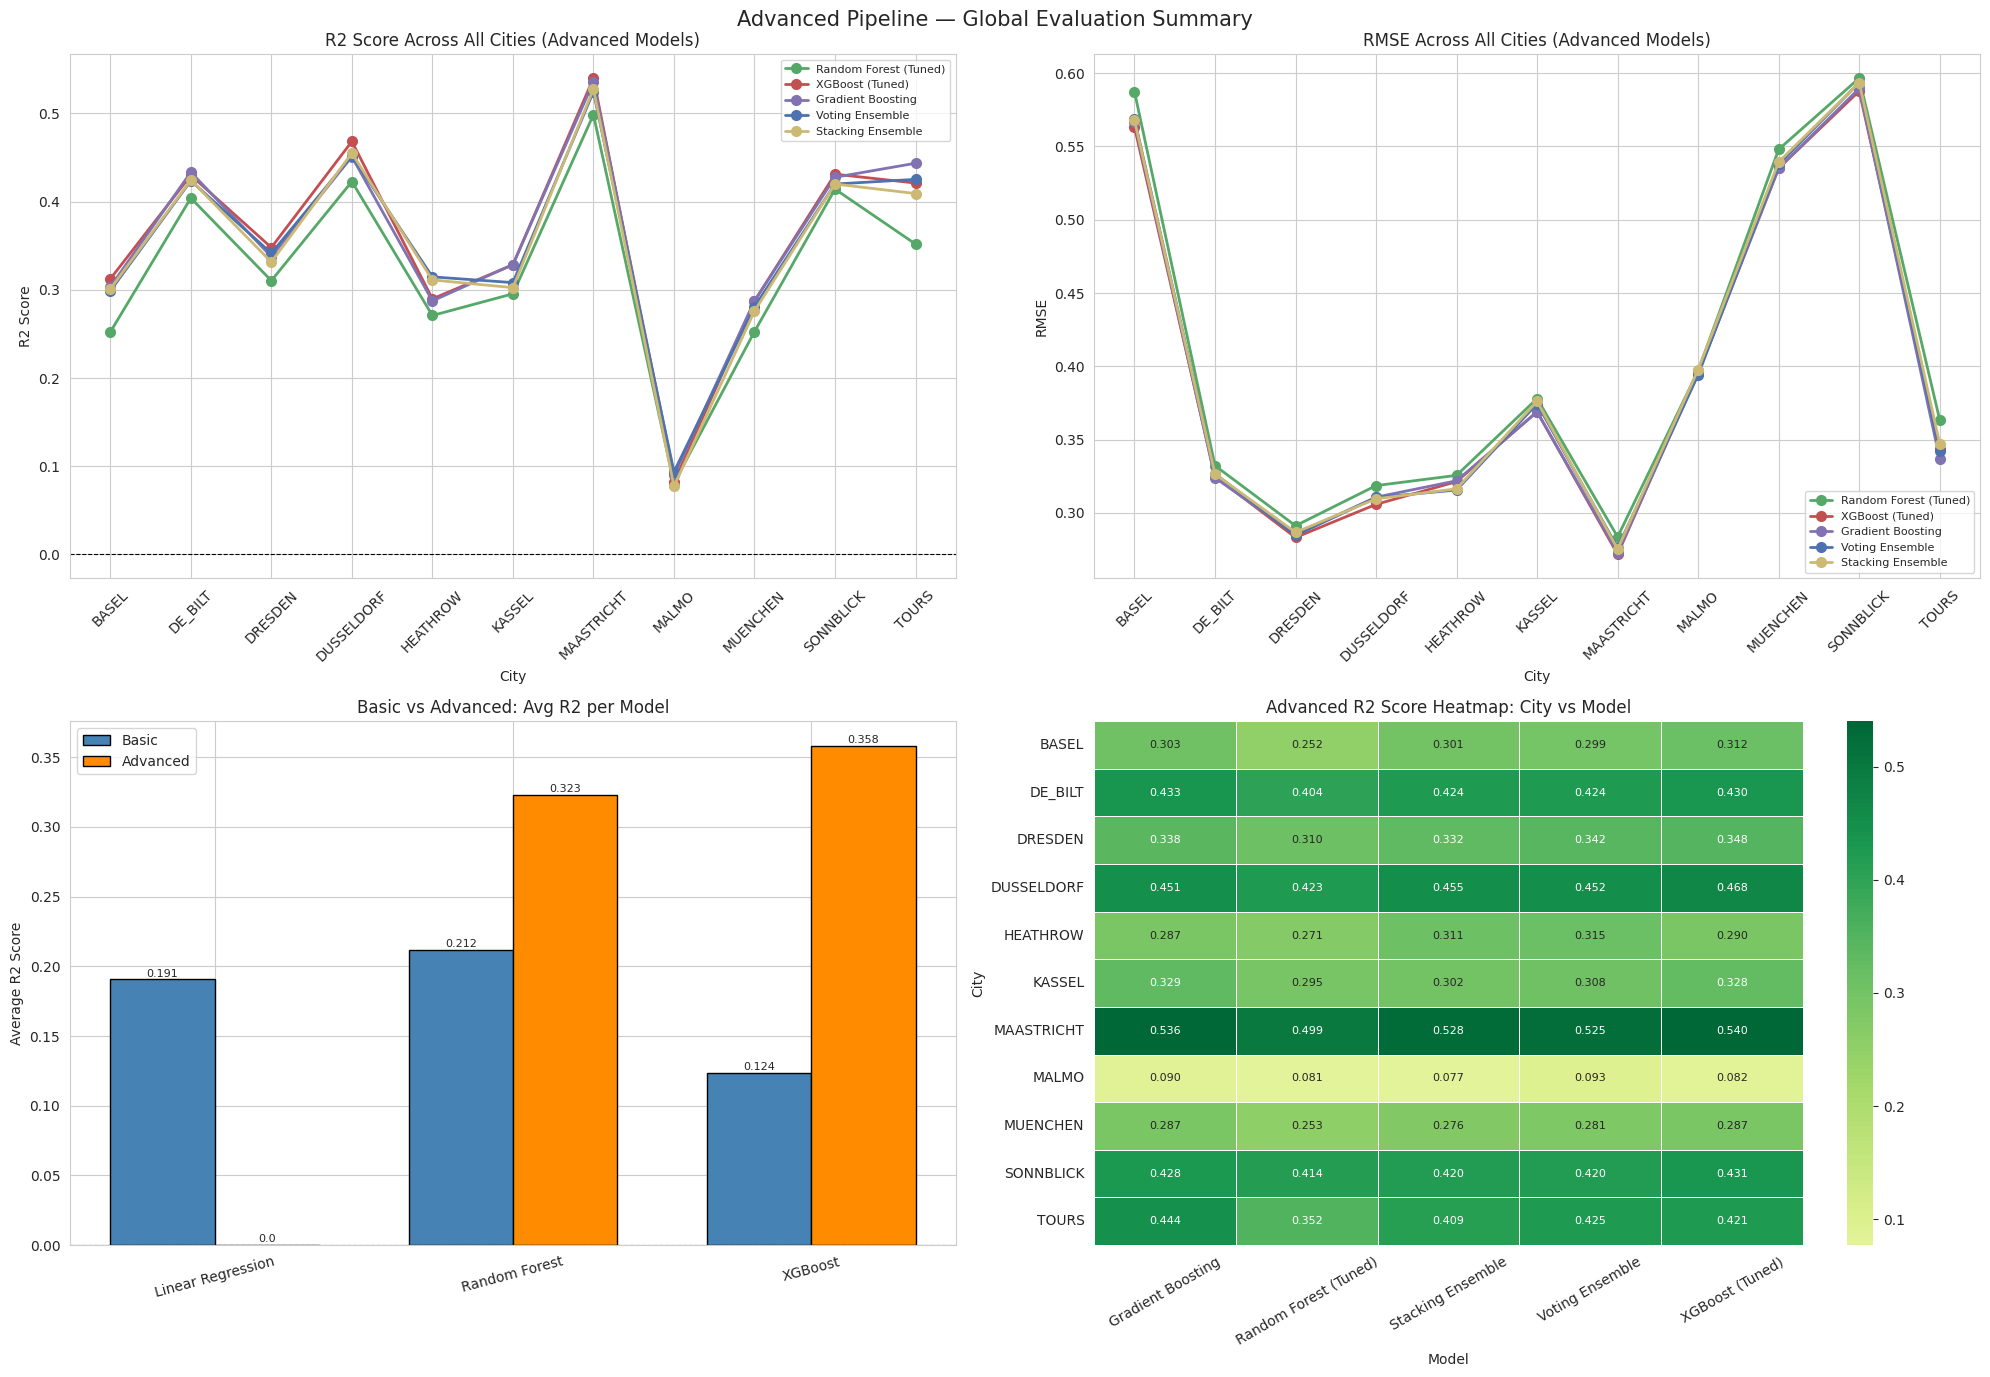

In [ ]:
# Advanced Global Visualisation

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

adv_model_colors = {
    'Random Forest (Tuned)' : '#55A868',
    'XGBoost (Tuned)'       : '#C44E52',
    'Gradient Boosting'     : '#8172B2',
    'Voting Ensemble'       : '#4C72B0',
    'Stacking Ensemble'     : '#CCB974'
}

# Plot 1: R2 Score per city per model
for model_name, color in adv_model_colors.items():
    subset = advanced_df[advanced_df['Model'] == model_name]
    axes[0][0].plot(
        subset['City'], subset['R2_Score'],
        marker='o', label=model_name,
        color=color, linewidth=2, markersize=7
    )
axes[0][0].set_title('R2 Score Across All Cities (Advanced Models)')
axes[0][0].set_xlabel('City')
axes[0][0].set_ylabel('R2 Score')
axes[0][0].tick_params(axis='x', rotation=45)
axes[0][0].legend(fontsize=8)
axes[0][0].axhline(0, color='black', linewidth=0.8, linestyle='--')

# Plot 2: RMSE per city per model
for model_name, color in adv_model_colors.items():
    subset = advanced_df[advanced_df['Model'] == model_name]
    axes[0][1].plot(
        subset['City'], subset['RMSE'],
        marker='o', label=model_name,
        color=color, linewidth=2, markersize=7
    )
axes[0][1].set_title('RMSE Across All Cities (Advanced Models)')
axes[0][1].set_xlabel('City')
axes[0][1].set_ylabel('RMSE')
axes[0][1].tick_params(axis='x', rotation=45)
axes[0][1].legend(fontsize=8)

# Plot 3: Basic vs Advanced avg R2 per model category
categories   = ['Linear Regression', 'Random Forest', 'XGBoost']
basic_vals   = [basic_model_avg.get(m, 0) for m in categories]
adv_names    = ['Linear Regression', 'Random Forest (Tuned)', 'XGBoost (Tuned)']
adv_vals     = [adv_model_avg.get(m, 0) for m in adv_names]

x      = np.arange(len(categories))
width  = 0.35

bars1  = axes[1][0].bar(x - width/2, basic_vals, width,
                         label='Basic', color='steelblue', edgecolor='black')
bars2  = axes[1][0].bar(x + width/2, adv_vals,   width,
                         label='Advanced', color='darkorange', edgecolor='black')

axes[1][0].set_title('Basic vs Advanced: Avg R2 per Model')
axes[1][0].set_xticks(x)
axes[1][0].set_xticklabels(categories, rotation=15)
axes[1][0].set_ylabel('Average R2 Score')
axes[1][0].legend()
axes[1][0].axhline(0, color='black', linewidth=0.8, linestyle='--')

for bar in bars1:
    axes[1][0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.002,
        str(round(bar.get_height(), 3)),
        ha='center', fontsize=8
    )
for bar in bars2:
    axes[1][0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.002,
        str(round(bar.get_height(), 3)),
        ha='center', fontsize=8
    )

# Plot 4: Advanced R2 Heatmap
pivot_adv = advanced_df.pivot(
    index='City', columns='Model', values='R2_Score'
)
sns.heatmap(
    pivot_adv, annot=True, fmt='.3f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, annot_kws={'size': 8},
    ax=axes[1][1]
)
axes[1][1].set_title('Advanced R2 Score Heatmap: City vs Model')
axes[1][1].set_xlabel('Model')
axes[1][1].set_ylabel('City')
axes[1][1].tick_params(axis='x', rotation=30)

plt.suptitle('Advanced Pipeline — Global Evaluation Summary', fontsize=15)
plt.tight_layout()
plt.show()

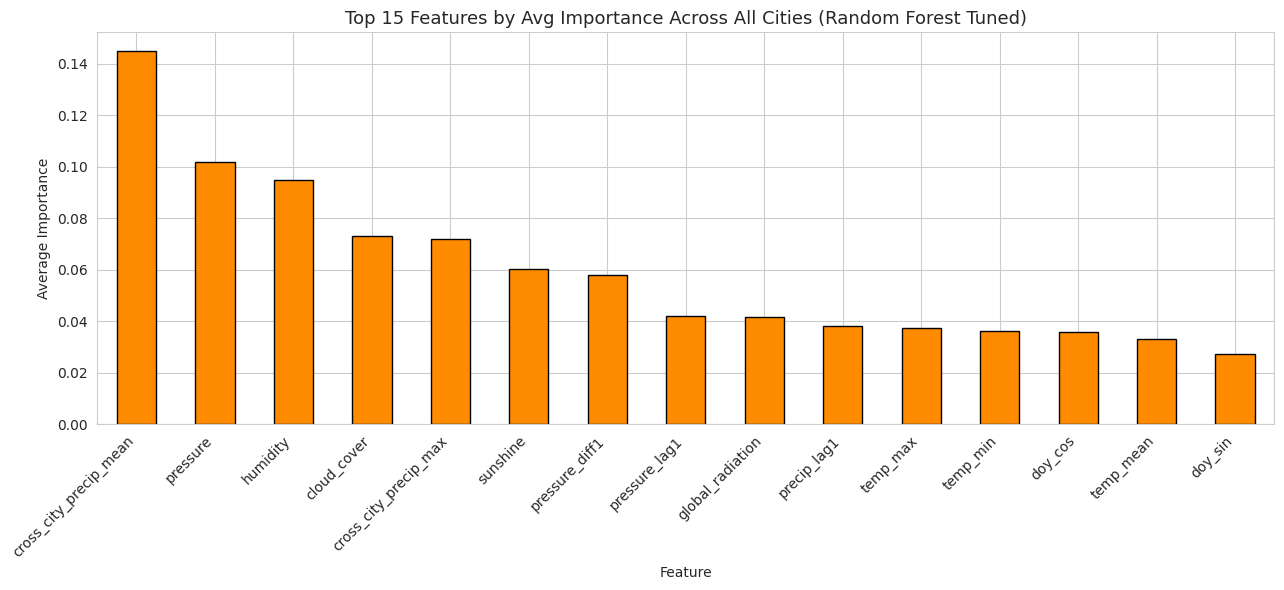

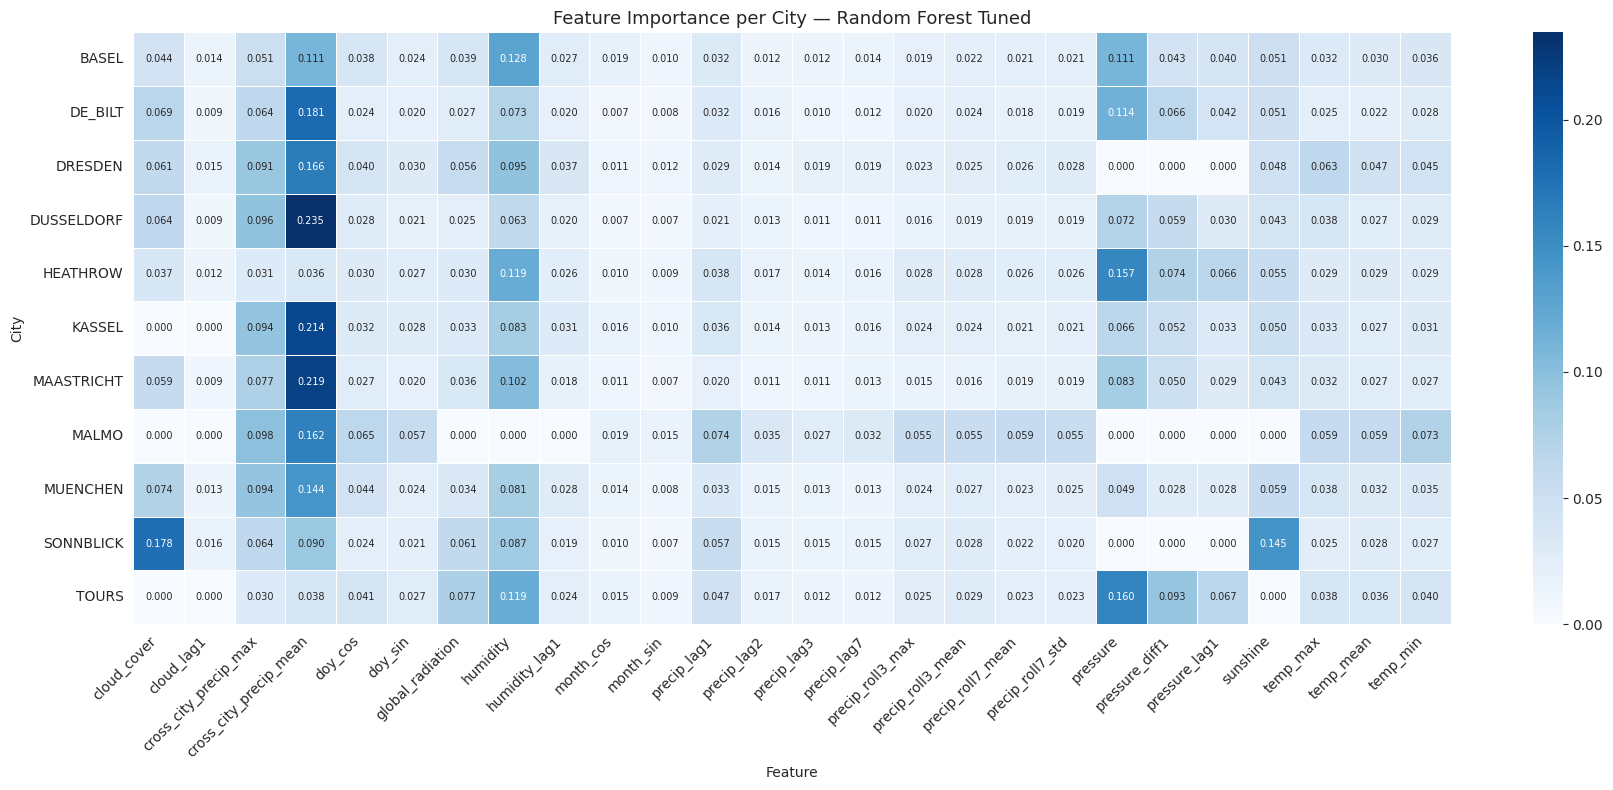


Top 10 Most Important Features Globally:

Feature
cross_city_precip_mean    0.1450
pressure                  0.1017
humidity                  0.0949
cloud_cover               0.0731
cross_city_precip_max     0.0718
sunshine                  0.0604
pressure_diff1            0.0579
pressure_lag1             0.0419
global_radiation          0.0418
precip_lag1               0.0381



In [ ]:
# Advanced Feature Importance Across All Cities

all_adv_importances = []

for city in cities_with_precip:
    if city == 'avg':
        continue

    model = advanced_models[city]['Random Forest (Tuned)']

    if hasattr(model, 'feature_importances_'):
        X, y, y_log, feat_names = engineer_features(
            df, city, city_features
        )
        imp            = pd.Series(
            model.feature_importances_,
            index=feat_names
        )
        imp_df         = imp.reset_index()
        imp_df.columns = ['Feature', 'Importance']
        imp_df['City'] = city

        # Normalise feature names by removing city prefix
        imp_df['Feature'] = imp_df['Feature'].str.replace(
            f'{city}_', '', regex=False
        )
        all_adv_importances.append(imp_df)

adv_importance_df = pd.concat(all_adv_importances, ignore_index=True)

# Average importance per feature type across all cities
avg_adv_importance = adv_importance_df.groupby(
    'Feature'
)['Importance'].mean().sort_values(ascending=False)

# Top 15 features
top15 = avg_adv_importance.head(15)

plt.figure(figsize=(13, 6))
top15.plot(kind='bar', color='darkorange', edgecolor='black')
plt.title(
    'Top 15 Features by Avg Importance Across All Cities (Random Forest Tuned)',
    fontsize=13
)
plt.xlabel('Feature')
plt.ylabel('Average Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Heatmap: feature importance per city
pivot_imp = adv_importance_df.pivot_table(
    index='City', columns='Feature',
    values='Importance', fill_value=0
)

plt.figure(figsize=(18, 8))
sns.heatmap(
    pivot_imp, annot=True, fmt='.3f',
    cmap='Blues', linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title(
    'Feature Importance per City — Random Forest Tuned',
    fontsize=13
)
plt.xlabel('Feature')
plt.ylabel('City')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print()
print("Top 10 Most Important Features Globally:")
print()
print(avg_adv_importance.head(10).round(4).to_string())

print()

In [ ]:
# Final Conclusion and Summary

print("=" * 70)
print("RAINFALL PREDICTION USING MACHINE LEARNING")
print("Final Results Summary")
print("=" * 70)

print()
print("DATASET OVERVIEW")
print("-" * 70)
print(f"  Source         : European Climate Assessment and Dataset (ECA&D)")
print(f"  Repository     : Zenodo (DOI: 10.5281/zenodo.5071376)")
print(f"  Period         : 2000 to 2010 (Daily Observations)")
print(f"  Total Records  : {df.shape[0]}")
print(f"  Cities Covered : {len(cities_with_precip)}")
print(f"  Cities         : {', '.join([c for c in cities_with_precip if c != 'avg'])}")

print()
print("PIPELINE COMPARISON OVERVIEW")
print("-" * 70)
print(f"  Basic Pipeline Models    : Linear Regression, Decision Tree,")
print(f"                             Random Forest, XGBoost")
print(f"  Advanced Pipeline Models : Random Forest (Tuned), XGBoost (Tuned),")
print(f"                             Gradient Boosting, Voting Ensemble,")
print(f"                             Stacking Ensemble")
print()
print("  Advanced Pipeline Enhancements:")
print("    - Log transformation on target variable")
print("    - Lag features  (1, 2, 3, 7 days)")
print("    - Rolling statistics (3-day and 7-day mean, max, std)")
print("    - Seasonal encoding (sine and cosine of month and day of year)")
print("    - Cross-city average precipitation feature")
print("    - Pressure difference feature")
print("    - Humidity and cloud cover lag features")

print()
print("=" * 70)
print("BASIC PIPELINE RESULTS")
print("=" * 70)

basic_summary = results_df.groupby('Model')[
    ['MAE', 'RMSE', 'R2_Score']
].mean().round(4).sort_values('R2_Score', ascending=False)

display(basic_summary)

print()
print("Best Model (Basic Pipeline):")
best_basic = basic_summary['R2_Score'].idxmax()
print(f"  Model    : {best_basic}")
print(f"  Avg R2   : {basic_summary.loc[best_basic, 'R2_Score']}")
print(f"  Avg RMSE : {basic_summary.loc[best_basic, 'RMSE']}")
print(f"  Avg MAE  : {basic_summary.loc[best_basic, 'MAE']}")

print()
print("=" * 70)
print("ADVANCED PIPELINE RESULTS")
print("=" * 70)

adv_summary = advanced_df.groupby('Model')[
    ['MAE', 'RMSE', 'R2_Score']
].mean().round(4).sort_values('R2_Score', ascending=False)

display(adv_summary)

print()
print("Best Model (Advanced Pipeline):")
best_adv = adv_summary['R2_Score'].idxmax()
print(f"  Model    : {best_adv}")
print(f"  Avg R2   : {adv_summary.loc[best_adv, 'R2_Score']}")
print(f"  Avg RMSE : {adv_summary.loc[best_adv, 'RMSE']}")
print(f"  Avg MAE  : {adv_summary.loc[best_adv, 'MAE']}")

print()
print("=" * 70)
print("IMPROVEMENT SUMMARY (Basic vs Advanced)")
print("=" * 70)

display(improvement_df)

print()
print("=" * 70)
print("CITY-LEVEL FINDINGS")
print("=" * 70)

print()
print("Basic Pipeline — Best Model Per City:")
display(best_per_city[['City', 'Model', 'MAE', 'RMSE', 'R2_Score']])

print()
print("Advanced Pipeline — Best Model Per City:")
display(best_adv_per_city[['City', 'Model', 'MAE', 'RMSE', 'R2_Score']])

print()
print("Easiest City to Predict:")
city_adv_avg = advanced_df.groupby('City')['R2_Score'].mean().sort_values(
    ascending=False
)
print(f"  {city_adv_avg.index[0]} -> Avg R2: {round(city_adv_avg.iloc[0], 4)}")

print()
print("Hardest City to Predict:")
print(f"  {city_adv_avg.index[-1]} -> Avg R2: {round(city_adv_avg.iloc[-1], 4)}")
print(f"  Reason: MALMO has only 4 features available (no humidity,")
print(f"          pressure, or cloud cover), limiting model performance.")

print()
print("=" * 70)
print("FEATURE IMPORTANCE FINDINGS")
print("=" * 70)

print()
print("Top 10 Most Predictive Features Globally (Random Forest Tuned):")
print()
print(avg_adv_importance.head(10).round(4).to_string())

RAINFALL PREDICTION USING MACHINE LEARNING
Final Results Summary

DATASET OVERVIEW
----------------------------------------------------------------------
  Source         : European Climate Assessment and Dataset (ECA&D)
  Repository     : Zenodo (DOI: 10.5281/zenodo.5071376)
  Period         : 2000 to 2010 (Daily Observations)
  Total Records  : 3654
  Cities Covered : 12
  Cities         : BASEL, DE_BILT, DRESDEN, DUSSELDORF, HEATHROW, KASSEL, MAASTRICHT, MALMO, MUENCHEN, SONNBLICK, TOURS

PIPELINE COMPARISON OVERVIEW
----------------------------------------------------------------------
  Basic Pipeline Models    : Linear Regression, Decision Tree,
                             Random Forest, XGBoost
  Advanced Pipeline Models : Random Forest (Tuned), XGBoost (Tuned),
                             Gradient Boosting, Voting Ensemble,
                             Stacking Ensemble

  Advanced Pipeline Enhancements:
    - Log transformation on target variable
    - Lag features  (1, 2, 3

,MAE,RMSE,R2_Score
Model,,,
Random Forest,0.2343,0.4140,0.2119
Linear Regression,0.2624,0.4221,0.1906
XGBoost,0.2452,0.4361,0.1236
Decision Tree,0.2932,0.5684,-0.5268



Best Model (Basic Pipeline):
  Model    : Random Forest
  Avg R2   : 0.2119
  Avg RMSE : 0.414
  Avg MAE  : 0.2343

ADVANCED PIPELINE RESULTS


,MAE,RMSE,R2_Score
Model,,,
XGBoost (Tuned),0.1930,0.3911,0.3580
Gradient Boosting,0.1942,0.3916,0.3569
Voting Ensemble,0.1944,0.3932,0.3530
Stacking Ensemble,0.1945,0.3942,0.3487
Random Forest (Tuned),0.2022,0.4020,0.3231



Best Model (Advanced Pipeline):
  Model    : XGBoost (Tuned)
  Avg R2   : 0.358
  Avg RMSE : 0.3911
  Avg MAE  : 0.193

IMPROVEMENT SUMMARY (Basic vs Advanced)


...


CITY-LEVEL FINDINGS

Basic Pipeline — Best Model Per City:


,City,Model,MAE,RMSE,R2_Score
0,BASEL,Random Forest,0.2346,0.4607,0.2726
1,DE_BILT,Random Forest,0.2257,0.3884,0.2676
2,DRESDEN,Random Forest,0.1908,0.3627,0.1338
3,DUSSELDORF,Random Forest,0.2293,0.4499,0.2048
4,HEATHROW,Linear Regression,0.1950,0.3050,0.2720
5,KASSEL,Random Forest,0.2134,0.3556,0.2273
6,MAASTRICHT,Random Forest,0.2002,0.3630,0.3431
7,MALMO,Linear Regression,0.2026,0.3086,0.0414
8,MUENCHEN,Random Forest,0.2725,0.5283,0.2138
9,SONNBLICK,Random Forest,0.4474,0.6808,0.2909



Advanced Pipeline — Best Model Per City:


,City,Model,MAE,RMSE,R2_Score
0,BASEL,XGBoost (Tuned),0.2338,0.5632,0.3124
1,DE_BILT,Gradient Boosting,0.1718,0.3239,0.4335
2,DRESDEN,XGBoost (Tuned),0.1493,0.2832,0.3480
3,DUSSELDORF,XGBoost (Tuned),0.1650,0.3058,0.4683
4,HEATHROW,Voting Ensemble,0.1572,0.3156,0.3147
5,KASSEL,Gradient Boosting,0.1682,0.3689,0.3287
6,MAASTRICHT,XGBoost (Tuned),0.1427,0.2717,0.5401
7,MALMO,Voting Ensemble,0.1925,0.3942,0.0935
8,MUENCHEN,Gradient Boosting,0.2313,0.5351,0.2875
9,SONNBLICK,XGBoost (Tuned),0.3565,0.5878,0.4312



Easiest City to Predict:
  MAASTRICHT -> Avg R2: 0.5254

Hardest City to Predict:
  MALMO -> Avg R2: 0.0846
  Reason: MALMO has only 4 features available (no humidity,
          pressure, or cloud cover), limiting model performance.

FEATURE IMPORTANCE FINDINGS

Top 10 Most Predictive Features Globally (Random Forest Tuned):

Feature
cross_city_precip_mean    0.1450
pressure                  0.1017
humidity                  0.0949
cloud_cover               0.0731
cross_city_precip_max     0.0718
sunshine                  0.0604
pressure_diff1            0.0579
pressure_lag1             0.0419
global_radiation          0.0418
precip_lag1               0.0381


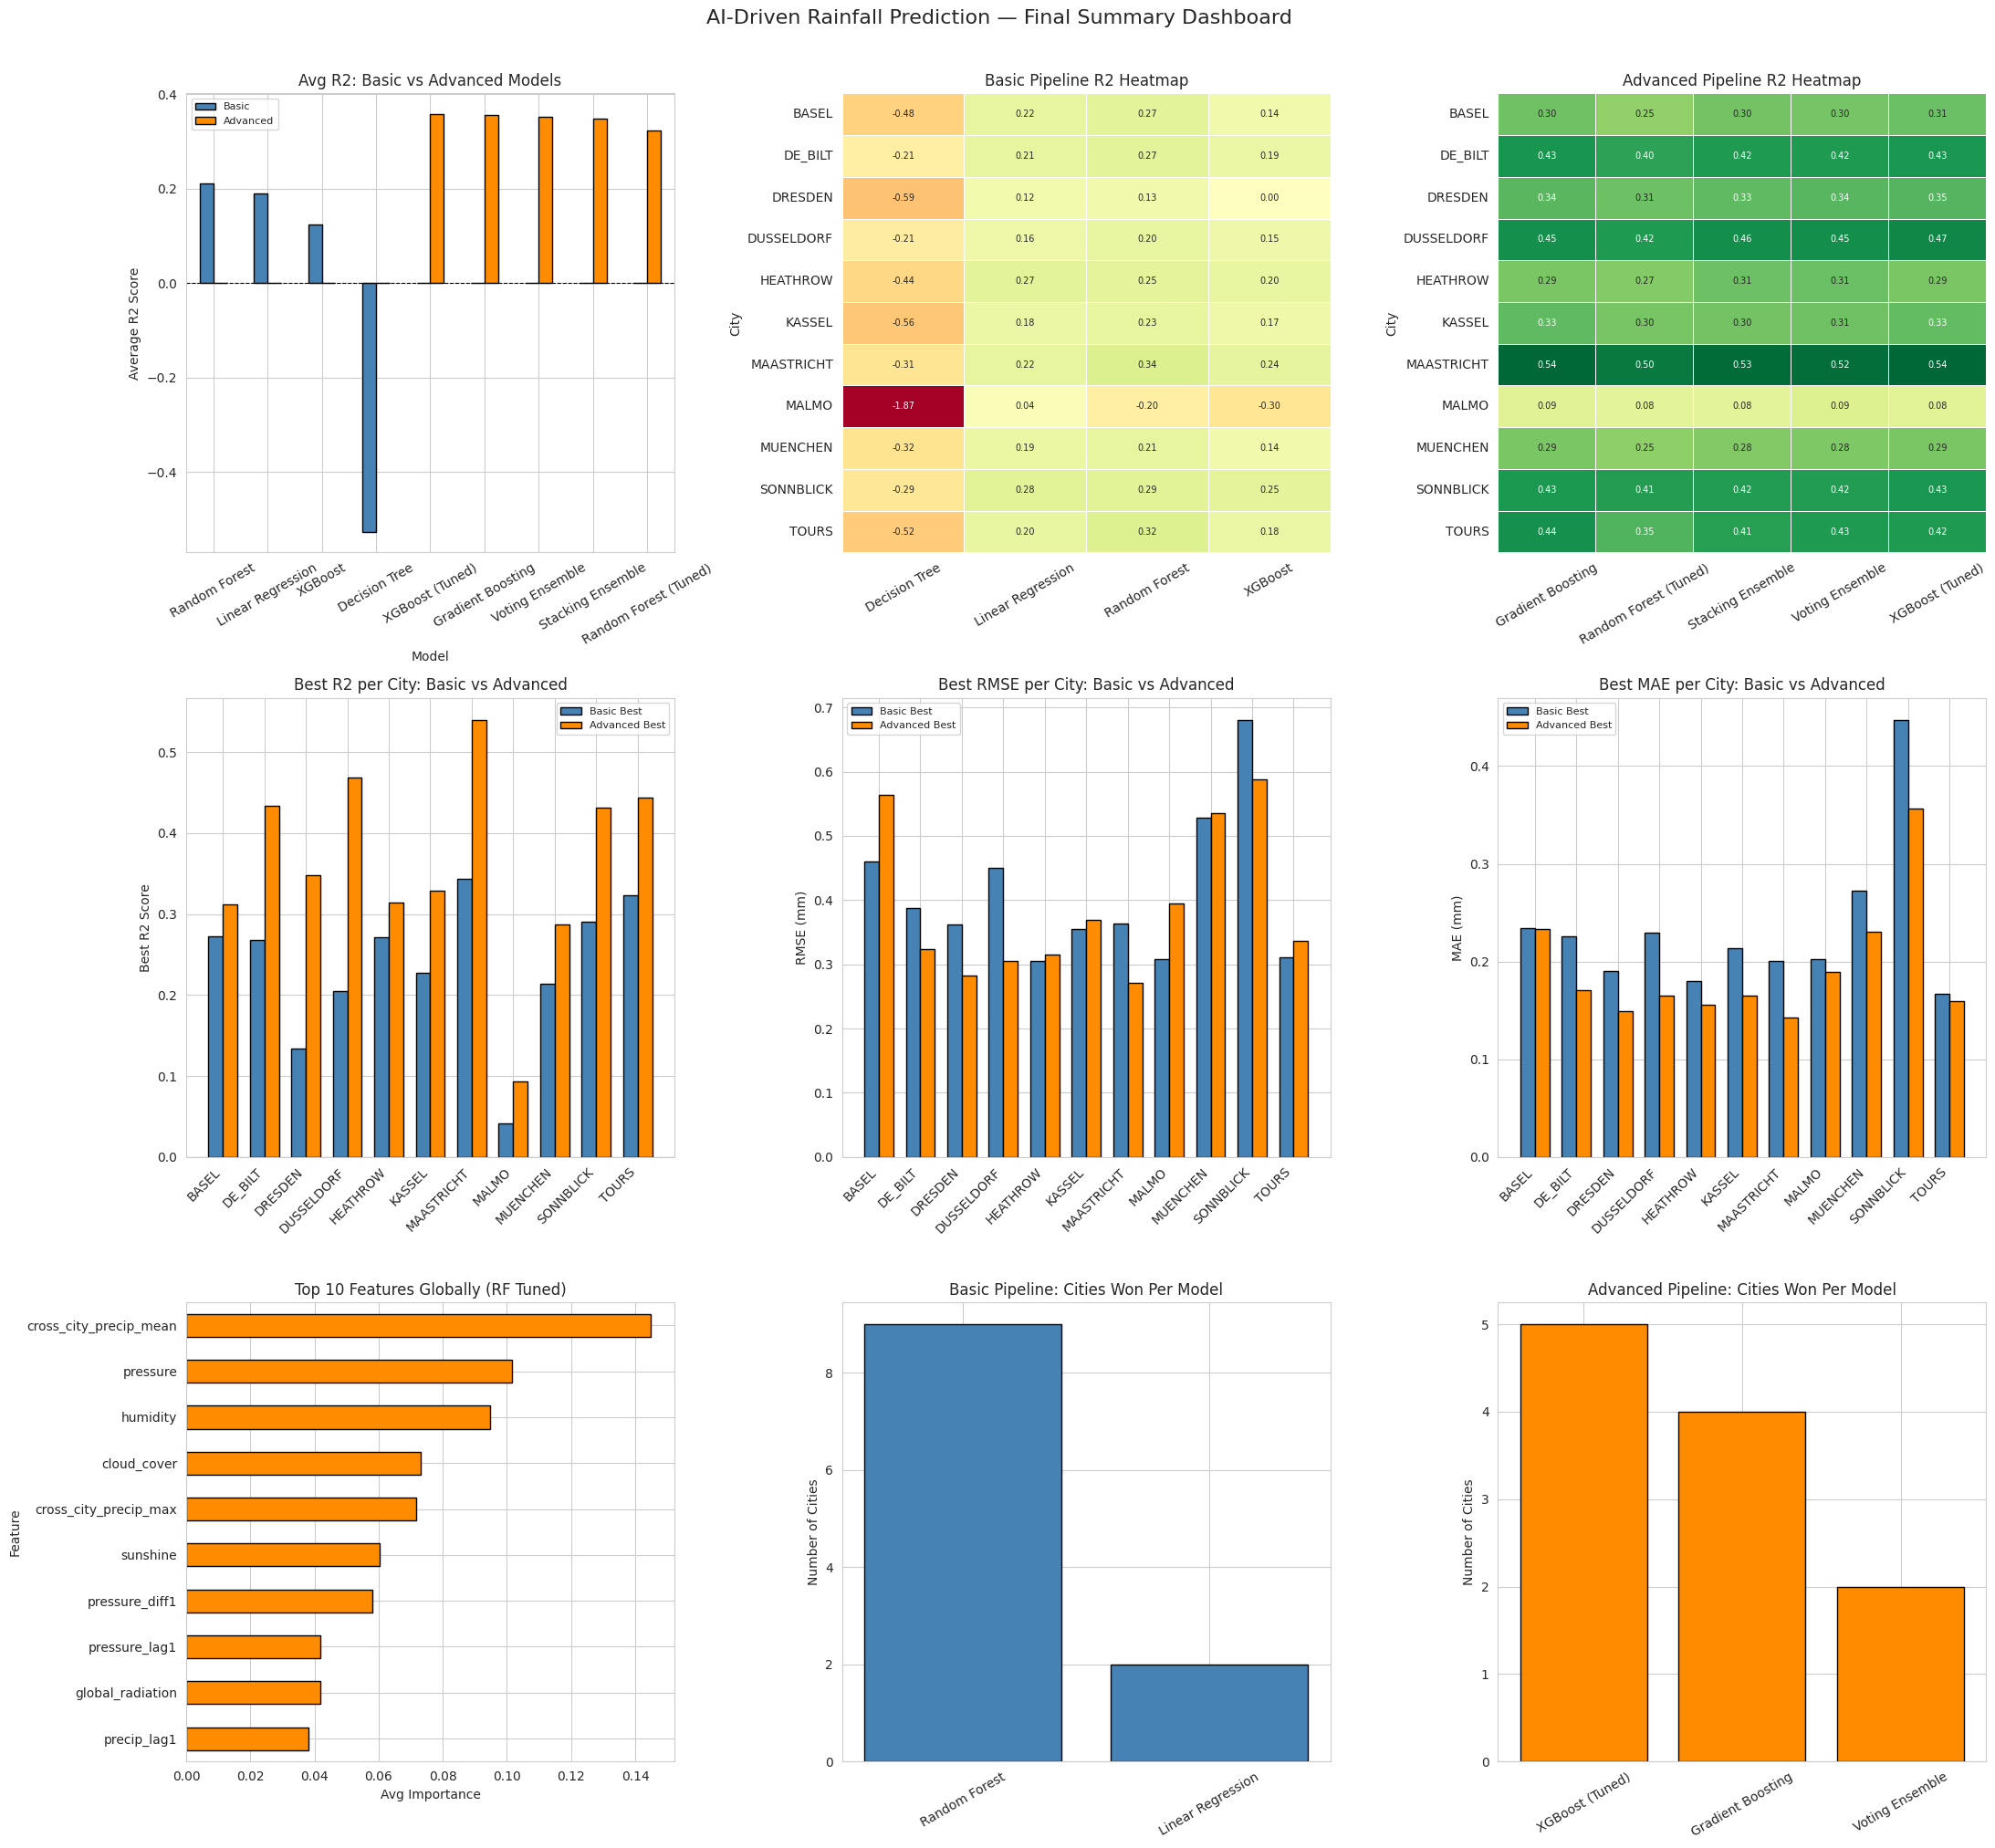

In [ ]:
# Final Visualisation Dashboard

fig = plt.figure(figsize=(22, 20))

# Plot 1: Basic vs Advanced avg R2 all models
ax1 = fig.add_subplot(3, 3, 1)
all_models_r2 = pd.concat([
    basic_summary['R2_Score'].rename('Basic'),
    adv_summary['R2_Score'].rename('Advanced')
], axis=1).fillna(0)

all_models_r2.plot(kind='bar', ax=ax1,
                   color=['steelblue', 'darkorange'],
                   edgecolor='black')
ax1.set_title('Avg R2: Basic vs Advanced Models')
ax1.set_ylabel('Average R2 Score')
ax1.set_xlabel('Model')
ax1.tick_params(axis='x', rotation=30)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.legend(fontsize=8)

# Plot 2: Basic pipeline R2 heatmap
ax2 = fig.add_subplot(3, 3, 2)
pivot_basic = results_df.pivot(
    index='City', columns='Model', values='R2_Score'
)
sns.heatmap(pivot_basic, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            linewidths=0.5, annot_kws={'size': 7},
            ax=ax2, cbar=False)
ax2.set_title('Basic Pipeline R2 Heatmap')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=30)

# Plot 3: Advanced pipeline R2 heatmap
ax3 = fig.add_subplot(3, 3, 3)
pivot_adv = advanced_df.pivot(
    index='City', columns='Model', values='R2_Score'
)
sns.heatmap(pivot_adv, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            linewidths=0.5, annot_kws={'size': 7},
            ax=ax3, cbar=False)
ax3.set_title('Advanced Pipeline R2 Heatmap')
ax3.set_xlabel('')
ax3.tick_params(axis='x', rotation=30)

# Plot 4: R2 score per city - best basic vs best advanced
ax4 = fig.add_subplot(3, 3, 4)
best_basic_city  = results_df.groupby('City')['R2_Score'].max()
best_adv_city    = advanced_df.groupby('City')['R2_Score'].max()

x      = np.arange(len(best_basic_city))
width  = 0.35

bars1 = ax4.bar(x - width/2, best_basic_city.values, width,
                label='Basic Best', color='steelblue', edgecolor='black')
bars2 = ax4.bar(x + width/2, best_adv_city.values,   width,
                label='Advanced Best', color='darkorange', edgecolor='black')

ax4.set_title('Best R2 per City: Basic vs Advanced')
ax4.set_xticks(x)
ax4.set_xticklabels(best_basic_city.index, rotation=45, ha='right')
ax4.set_ylabel('Best R2 Score')
ax4.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax4.legend(fontsize=8)

# Plot 5: RMSE comparison per city
ax5 = fig.add_subplot(3, 3, 5)
basic_rmse = results_df.groupby('City')['RMSE'].min()
adv_rmse   = advanced_df.groupby('City')['RMSE'].min()

x     = np.arange(len(basic_rmse))
bars3 = ax5.bar(x - width/2, basic_rmse.values, width,
                label='Basic Best', color='steelblue', edgecolor='black')
bars4 = ax5.bar(x + width/2, adv_rmse.values,   width,
                label='Advanced Best', color='darkorange', edgecolor='black')

ax5.set_title('Best RMSE per City: Basic vs Advanced')
ax5.set_xticks(x)
ax5.set_xticklabels(basic_rmse.index, rotation=45, ha='right')
ax5.set_ylabel('RMSE (mm)')
ax5.legend(fontsize=8)

# Plot 6: MAE comparison per city
ax6 = fig.add_subplot(3, 3, 6)
basic_mae = results_df.groupby('City')['MAE'].min()
adv_mae   = advanced_df.groupby('City')['MAE'].min()

x     = np.arange(len(basic_mae))
ax6.bar(x - width/2, basic_mae.values, width,
        label='Basic Best', color='steelblue', edgecolor='black')
ax6.bar(x + width/2, adv_mae.values,   width,
        label='Advanced Best', color='darkorange', edgecolor='black')

ax6.set_title('Best MAE per City: Basic vs Advanced')
ax6.set_xticks(x)
ax6.set_xticklabels(basic_mae.index, rotation=45, ha='right')
ax6.set_ylabel('MAE (mm)')
ax6.legend(fontsize=8)

# Plot 7: Top 10 feature importances globally
ax7 = fig.add_subplot(3, 3, 7)
top10 = avg_adv_importance.head(10)
top10.plot(kind='barh', ax=ax7,
           color='darkorange', edgecolor='black')
ax7.set_title('Top 10 Features Globally (RF Tuned)')
ax7.set_xlabel('Avg Importance')
ax7.invert_yaxis()

# Plot 8: Win count per model - basic
ax8 = fig.add_subplot(3, 3, 8)
basic_wins = best_per_city['Model'].value_counts()
ax8.bar(basic_wins.index, basic_wins.values,
        color='steelblue', edgecolor='black')
ax8.set_title('Basic Pipeline: Cities Won Per Model')
ax8.set_ylabel('Number of Cities')
ax8.tick_params(axis='x', rotation=30)

# Plot 9: Win count per model - advanced
ax9 = fig.add_subplot(3, 3, 9)
adv_wins = best_adv_per_city['Model'].value_counts()
ax9.bar(adv_wins.index, adv_wins.values,
        color='darkorange', edgecolor='black')
ax9.set_title('Advanced Pipeline: Cities Won Per Model')
ax9.set_ylabel('Number of Cities')
ax9.tick_params(axis='x', rotation=30)

plt.suptitle(
    'AI-Driven Rainfall Prediction — Final Summary Dashboard',
    fontsize=16, y=1.01
)
plt.tight_layout()
plt.show()